# Exploración de problemas - Dataset COVID-19

Datos extraídos de `covid.zip`. Este notebook carga cada archivo, revisa su estructura
y busca **problemas de calidad de datos**: valores nulos, tipos inconsistentes, fechas,
duplicados, valores negativos y distribuciones sospechosas.

Archivos disponibles:
- `covid_19_data.csv` – contiene reportes diarios acumulados de contagios a nivel global.
- `time_series_covid_19_confirmed.csv` / `_deaths.csv` / `_recovered.csv` – series temporales acumuladas por pais
- `time_series_covid_19_confirmed_US.csv` / `_deaths_US.csv` – reportes a nivel de condado en USA de casos de contagio y decesos.

In [1]:
import sys
from pathlib import Path

# Deteccion de entorno y rutas (relativas, no dependen de tu PC)
EN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path("/content") if EN_COLAB else Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"            # CSV originales
OUT_DIR  = BASE_DIR / "dataset_limpio"   # CSV limpios (salida)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_URL = "https://drive.google.com/drive/folders/1f7h8MFquqpaZRwq-4l3kcxshTJaILyuB?usp=sharing"
print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("Datos en:", DATA_DIR)
print("Salida en:", OUT_DIR)

Entorno: Local
Datos en: /home/azurduy/Universidad/machine-learning-primer-parcial/data
Salida en: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio


## 1. Configuracion Inicial
En esta parte se inicia con todo lo necesario para comenzar con el analisis y limpieza de los datos del dataset, ademas de su importacion como la declaracion del uso de librerias como se vera acontinuacion.

## 1.1. Importacion de Librerias:
Se incluyen las siguientes librerias junto con su proposito:
- **os:** libreria del sistema operativo para el manejo de importacion de los archicos csv
- **pandas:** libreria principal para el analisis de datos y consultas rapidas de las tablas importadas
- **numpy:** libreria para facilitar y optimizar operaciones matematicas y operaciones con listas con cantidades gigantes de valores.
- **mathplotlib y seaborn:** librerias para el renderizado de graficos estadisticos.
- **gdown:** libreria de compatibilidad con Google Drive para la descarga de archivos localmente.
- **glob:** libreria para buscar archivos en el disco que coincidan con un patrón de nombre.
- **re:** libreria principal para el manejo y manipulacion de expresiones regulares o regex

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown as gd
import glob as glob
import re

## 1.3. Descarga de los Archivos del Dataset
Se especifica la ruta o URL del repositorio de Google Drive donde se encuentran alojados los 6 archivos csv del dataset.

In [3]:
ARCHIVOS = {
    "global_data":   "covid_19_data.csv",
    "confirmed":     "time_series_covid_19_confirmed.csv",
    "confirmed_US":  "time_series_covid_19_confirmed_US.csv",
    "deaths":        "time_series_covid_19_deaths.csv",
    "deaths_US":     "time_series_covid_19_deaths_US.csv",
    "recovered":     "time_series_covid_19_recovered.csv",
}

def buscar(nombre):
    return next(DATA_DIR.rglob(nombre), None)

faltantes = [n for n in ARCHIVOS.values() if buscar(n) is None]

if faltantes:
    print("Faltan archivos, descargando desde Google Drive...")
    gd.download_folder(DRIVE_URL, output=str(DATA_DIR), quiet=False)
    faltantes = [n for n in ARCHIVOS.values() if buscar(n) is None]

if faltantes:
    raise FileNotFoundError(
        f"No se encontraron: {faltantes}. Coloca los CSV en la carpeta '{DATA_DIR}' y vuelve a ejecutar."
    )
print("Los 6 archivos estan disponibles.")

Los 6 archivos estan disponibles.


## 1.4. Lectura y Almacenamiento Provisional de Archivos del Dataset
Se leen los 6 archivos .csv del dataset con ayuda de la libreria pandas, y se los almacena en un diccionario, donde se les asigna un nombre mas corto y accesible a comparacion de su nombre original para facilitar su manejo y accesibilidad.

In [4]:
dfs = {clave: pd.read_csv(buscar(nombre)) for clave, nombre in ARCHIVOS.items()}

In [5]:
# Impresion de los nuevos nombres de los 6 archivos .csv del Dataset:
print("Tablas a analizar:", list(dfs.keys()))

Tablas a analizar: ['global_data', 'confirmed', 'confirmed_US', 'deaths', 'deaths_US', 'recovered']


## 1.5. Declaracion de Data Frames
En esta parte se declara un string llamado *currrent_csv_table* que apunta al nombre del la tabla de cualquiera de los 6 archivos .csv que se desee segun su nuevo nombre proporcionado.

In [6]:
current_csv_table = 'global_data'

Se declara un Data Frame generico que contiene toda la informacion de la tabla seleccionada anteriormente por el nombre contenido en el string, en este caso contendria la tabla de datos globales.

In [7]:
# Data Frame Generico:
df = pd.DataFrame(dfs[current_csv_table])

Se declaran 2 conjuntos de Data Frames extra que contendran las tablas correspondientes a cada uno de los 6 archivos .csv, el primer grupo de estos Data Frames serviran para compaeativas y explicacion del analisis y exploracion de anomalias en los registros y sus valores antes de la limpieza de datos, mientras que el segundo grupo se usara exclusivamente para la limpieza de datos.

In [8]:
# Grupo 1 de Data Frames para el Analisis
df1 = pd.DataFrame(dfs["global_data"])
df2 = pd.DataFrame(dfs["confirmed"])
df3 = pd.DataFrame(dfs['confirmed_US'])
df4 = pd.DataFrame(dfs["deaths"])
df5 = pd.DataFrame(dfs["deaths_US"])
df6 = pd.DataFrame(dfs["recovered"])

In [9]:
# Grupo 2 de Data Frames para la Limpieza
df1_ = pd.DataFrame(dfs["global_data"])
df2_ = pd.DataFrame(dfs["confirmed"])
df3_ = pd.DataFrame(dfs['confirmed_US'])
df4_ = pd.DataFrame(dfs["deaths"])
df5_ = pd.DataFrame(dfs["deaths_US"])
df6_ = pd.DataFrame(dfs["recovered"])

# 2. Analisis General de la Tabla

Aqui comienza el analisis y limpieza de los datos, para ello se comienza con un vistazo general de todas y cada una de las tablas, sus registros, valores y contenido en general, junto con algunas propiedades interesantes que se podran apreciar a continuacion.

## 1.1. Analisis Detallado
A continuacion se explicara paso a paso como se ha planteado el analisis general de tablas para la identificacion de problemas en los datos que contienen de manera general

La funcion *head()* ayuda a ver las primeras columnas de una tabla o Data Frame, lo cual es util para hacerse una idea de como es la estructura de los datos en cuanto a filas (registros) y columnas (categorias)

In [10]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


Tambien es posible obtener otra informacion interesante como es las dimensiones de la tabla que refleja cuantas columnas y filas tiene por medio de los atributos *shape* y *size* propios de los Data Frames

In [11]:
table_dim = df.shape
total_elements = df.size
print("Dimensiones:", table_dim[0], "filas y", table_dim[1], "columnas.")
print("Cantidad de elementos totales:", total_elements)

Dimensiones: 306429 filas y 8 columnas.
Cantidad de elementos totales: 2451432


Haciendo uso de la funcion *info()* es posible obtener un resumen general estructural de como es que esta construida la tabla a analizar, incluyendo informacion escencial como ser: nombre de las columnas/categorias, cantidad de valores no nulos y los tipos de datos de los valores que contiene cada columna como se aprecia.

In [12]:
print("Informacion de columnas:", '\n')
df.info()

Informacion de columnas: 

<class 'pandas.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  str    
 2   Province/State   228326 non-null  str    
 3   Country/Region   306429 non-null  str    
 4   Last Update      306429 non-null  str    
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 18.7 MB


Otra forma de comprender la estructura de la tabla a analizar es mediante resumenes estadisticos que reflejan propiedades ligadas a como se comportan los valores contenidos en las categorias. La funcion *describe()* precisamente genera un resumen estadistico de las columnas con valores numericos que refleja las siguientes propiedades: cantidad de filas, mediana, desviacion estandar, valor minimo, cuartiles y valor maximo.

In [13]:
print("Resumen Estadistico de Valores Numericos de la tabla:")
df.describe()

Resumen Estadistico de Valores Numericos de la tabla:


,SNo,Confirmed,Deaths,Recovered
count,306429.000000,3.064290e+05,306429.000000,3.064290e+05
mean,153215.000000,8.567091e+04,2036.403268,5.042029e+04
std,88458.577156,2.775516e+05,6410.938048,2.015124e+05
min,1.000000,-3.028440e+05,-178.000000,-8.544050e+05
25%,76608.000000,1.042000e+03,13.000000,1.100000e+01
50%,153215.000000,1.037500e+04,192.000000,1.751000e+03
75%,229822.000000,5.075200e+04,1322.000000,2.027000e+04
max,306429.000000,5.863138e+06,112385.000000,6.399531e+06


El resumen estadistico mostrado tambien se puede aplicar a columnas no numericas, para ello solo se debe especificar incluir aquellas categorias que tienen el tipo de dato object o cualquier otro tipo de dato no numerico como se observa.

In [14]:
print("Resumen Estadistico de Valores No Numericos de la tabla:")
df.describe(include="object")

Resumen Estadistico de Valores No Numericos de la tabla:


/tmp/ipykernel_22137/2416072623.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,ObservationDate,Province/State,Country/Region,Last Update
count,306429,228326,306429,306429
unique,494,736,229,1905
top,01/21/2021,Unknown,Russia,2021-04-02 15:13:53
freq,765,4123,30251,239885


## 1.2. Analisis Generalizado para Cualquier Tabla

A fines practicos se ha creado la funcion *general_analysis()* que brinda de forma generalizada para cualquier tabla un resumen que refleja todas las propiedades anteriores.

In [15]:
def general_analysis(dfx):
  print("Vista general de registros de la tabla")
  overview = dfx.head()
  print(overview, '\n')
  table_dim = dfx.shape
  total_elements = dfx.size
  print("Dimensiones:", table_dim[0], "filas y", table_dim[1], "columnas.")
  print("Cantidad de elementos totales:", total_elements, "\n")
  print("Informacion de columnas:")
  info = dfx.info()
  print(info, "\n")
  print("Resumen Estadistico de Valores Numericos de la tabla:")
  num_statistics = dfx.describe()
  print(num_statistics, '\n')
  print("Resumen Estadistico de Valores No Numericos de la tabla:")
  no_num_statistics = dfx.describe(include="object")
  print(no_num_statistics, '\n')

In [16]:
general_analysis(df)

Vista general de registros de la tabla
   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0   

Dimensiones: 306429 filas y 8 columnas.
Cantidad de elementos totales: 2451432 

Informacion de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo   

/tmp/ipykernel_22137/44642999.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  no_num_statistics = dfx.describe(include="object")


       ObservationDate Province/State Country/Region          Last Update
count           306429         228326         306429               306429
unique             494            736            229                 1905
top         01/21/2021        Unknown         Russia  2021-04-02 15:13:53
freq               765           4123          30251               239885 




# 2. Analisis de Datos Faltantes o Vacios



## 2.1. Analisis Detallado
A continuacion se explicara paso a paso como se ha planteado el analisis de tablas para la identificacion de problemas con datos faltantes o vacios dentro de los registros.


La mejor forma de comenzar el analisis e identificacion de este tipo de errores es consultando la cantidad de valores nulos que existen por columna, siendo que aquellas categorias con una cantidad distinta a 0 son categorias candidatas a ser limpiadas.

In [17]:
print("Cantidad de valores nulos por cada columna de la tabla:")
df.isnull().sum()

Cantidad de valores nulos por cada columna de la tabla:


SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64

Tambien es posible obtener la metrica anterior, pero en lugar de hacerlo por valores acumulados de frecuencia por aparicion, tambien se puede hacer por porcentaje de aparicion.

In [18]:
perc_col_null_elements = round(df.isnull().sum() / df.shape[0] * 100, 3)
print("Porcentaje de valores nulos por cada columna de la tabla:", "\n")
print(perc_col_null_elements.to_string())

Porcentaje de valores nulos por cada columna de la tabla: 

SNo                 0.000
ObservationDate     0.000
Province/State     25.488
Country/Region      0.000
Last Update         0.000
Confirmed           0.000
Deaths              0.000
Recovered           0.000


Finalmente para tener un panorama un poco mas general, tambien consulta la cantidad total de elememtos nulos en toda la tabla al igual que el porcentaje que representa esa cantidad de valores nulos respecto a todos los valores en la tabla

In [19]:
total_null_elements = df.isnull().sum().sum()
print("Cantidad total de elementos nulos en la tabla:", total_null_elements)

Cantidad total de elementos nulos en la tabla: 78103


In [20]:
perc_null_elements = total_null_elements / df.size * 100
print(round(perc_null_elements, 3), "% de la tabla los elementos son nulos.", sep = "")

3.186% de la tabla los elementos son nulos.


## 2.2. Analisis Generalizado para Cualquier Tabla
A fines practicos se ha creado la funcion *null_value_analysis()* que brinda de forma generalizada para cualquier tabla un resumen que refleja todas las propiedades anteriores para la identificacion de valores nulos.

In [21]:
def null_value_analysis(dfx):
  print("Cantidad de valores nulos por cada columna de la tabla:")
  nulls = dfx.isnull().sum()
  print(nulls, '\n')
  perc_col_null_elements = round(dfx.isnull().sum() / dfx.shape[0] * 100, 3)
  print("Porcentaje de valores nulos por cada columna de la tabla:")
  print(perc_col_null_elements.to_string(), '\n')
  total_null_elements = dfx.isnull().sum().sum()
  print("Cantidad total de elementos nulos en la tabla:", total_null_elements, '\n')
  perc_null_elements = total_null_elements / dfx.size * 100
  print(round(perc_null_elements, 3), "% de la tabla los elementos son nulos.", sep = "")

In [22]:
null_value_analysis(df6_)

Cantidad de valores nulos por cada columna de la tabla:
Province/State    191
Country/Region      0
Lat                 1
Long                1
1/22/20             0
                 ... 
5/25/21             0
5/26/21             0
5/27/21             0
5/28/21             0
5/29/21             0
Length: 498, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
Province/State    73.180
Country/Region     0.000
Lat                0.383
Long               0.383
1/22/20            0.000
1/23/20            0.000
1/24/20            0.000
1/25/20            0.000
1/26/20            0.000
1/27/20            0.000
1/28/20            0.000
1/29/20            0.000
1/30/20            0.000
1/31/20            0.000
2/1/20             0.000
2/2/20             0.000
2/3/20             0.000
2/4/20             0.000
2/5/20             0.000
2/6/20             0.000
2/7/20             0.000
2/8/20             0.000
2/9/20             0.000
2/10/20            0.000
2/11/20         

## 2.3. Limpieza de datos
La limpieza de datos para los valores nulos se puede llevar a cabo una vez identificado la influencia y aparicion de los mismos durante el analisis, en esta instancia de la limpieza es importante hacer una revision especifica de los datos de analisis de cada tabla como se hara a continuacion:

*Cabe recalcar que en esta fase, no se considera la normalizacion de los valores de las categorias puesto que eso se llevara a cabo mas adelante en el analisis de representaciones variadas de valores.*

### 2.3.1. Tabla de Datos Globales
* Tratamiento de Province/State (78,103 nulos): Reemplazar los valores faltantes por 'Unknown' resuelve la totalidad de la ausencia de datos en la matriz sin eliminar ninguna de las 306,429 observaciones. Esto previene perdidas de informacion en paises que reportan sus casos únicamente a nivel nacional.

In [23]:
# Remplazar valores de Province/State con Unknown:
df1_['Province/State'] = df1_['Province/State'].fillna('Unknown')

* No es necesario continuar con la depuracion de valores nulos con las columnas de **SNo, ObservationDate, Country/State, Last Update, Confirmed, Deaths** y **Recovered**, ya que segun el analisis no existen.


In [24]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df1_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
SNo                0
ObservationDate    0
Province/State     0
Country/Region     0
Last Update        0
Confirmed          0
Deaths             0
Recovered          0
dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
SNo                0.0
ObservationDate    0.0
Province/State     0.0
Country/Region     0.0
Last Update        0.0
Confirmed          0.0
Deaths             0.0
Recovered          0.0 

Cantidad total de elementos nulos en la tabla: 0 

0.0% de la tabla los elementos son nulos.


### 2.3.2. Tabla de Casos Confirmados
* Relleno de Province/State con Country/Region: Segun el resultado del analisis realizado para esta tabla es una situacion similar a la anterior tabla, por tanto lo mejor es rellenar los 190 valores nulos con el valor "Unknown".

In [25]:
# Remplazar valores de Province/State con Unknown:
df2_['Province/State'] = df2_['Province/State'].fillna('Unknown')

* Coordenadas geograficas (Lat, Long): no es ideal dejar estos campos vacios, sin embargo rellenarlos como sea tampoco es opcion, se descarta la opcion de rellenar coon 0s y con valores estadisticos como la media, mediana o moda, puesto que existe una especie de dependencia entre estos datos y el lugar especificado en las categorias de **Province/State** y **Country/Region**, por tanto se optara por borrar los 2 registros que tienen nulos esos valores.

In [26]:
print("Antes de la eliminacion:", df2_.shape[0], "registros.")
df2_ = df2_.dropna(subset=['Lat', 'Long'])
print("Despues de la eliminacion", df2_.shape[0], "registros.")

Antes de la eliminacion: 276 registros.
Despues de la eliminacion 274 registros.


- No es necesario continuar con la depuracion de valores nulos con las columnas de **Country/State** y **Categorias de Fechas (dd/mm/aa)**, ya que segun el analisis no existen.

In [27]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df2_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
Province/State    0
Country/Region    0
Lat               0
Long              0
1/22/20           0
                 ..
5/25/21           0
5/26/21           0
5/27/21           0
5/28/21           0
5/29/21           0
Length: 498, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
Province/State    0.0
Country/Region    0.0
Lat               0.0
Long              0.0
1/22/20           0.0
1/23/20           0.0
1/24/20           0.0
1/25/20           0.0
1/26/20           0.0
1/27/20           0.0
1/28/20           0.0
1/29/20           0.0
1/30/20           0.0
1/31/20           0.0
2/1/20            0.0
2/2/20            0.0
2/3/20            0.0
2/4/20            0.0
2/5/20            0.0
2/6/20            0.0
2/7/20            0.0
2/8/20            0.0
2/9/20            0.0
2/10/20           0.0
2/11/20           0.0
2/12/20           0.0
2/13/20           0.0
2/14/20   

### 2.3.3. Tabla de Casos Confirmados en USA

* Identificadores locales (Admin2 y FIPS): En el dataset de EE.UU., Admin2 representa el condado y FIPS el codigo de identificacion condal.
- **Admin2:** Para el caso de Admin2 es posible evitar eliminar los valores nulos asignando un valor de desconocimiento como "Unassigned".



In [28]:
# Remplazar valores de Admin2 con Unassigned:
df3_['Admin2'] = df3_['Admin2'].fillna('Unassigned')

- **FIPS:** por otro lado para esta categoria no es prudente asignar un valor de nulidad como el 0, ya que el valor de esta columna representa un codigo especifico de un condal en USA, poniendo 0 se pueden generar discrepancias con los valores de las categorias de **Province_State** e incluso **Country_Region**, es mejor depurar esos registros ademas de representar un porcentaje de 0.001 de perdida.

In [29]:
print("Antes de la eliminacion:", df3_.shape[0], "registros.")
df3_ = df3_.dropna(subset=['FIPS'])
print("Despues de la eliminacion", df3_.shape[0], "registros.")

Antes de la eliminacion: 3342 registros.
Despues de la eliminacion 3332 registros.


In [30]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df3_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
UID        0
iso2       0
iso3       0
code3      0
FIPS       0
          ..
5/25/21    0
5/26/21    0
5/27/21    0
5/28/21    0
5/29/21    0
Length: 505, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
UID               0.0
iso2              0.0
iso3              0.0
code3             0.0
FIPS              0.0
Admin2            0.0
Province_State    0.0
Country_Region    0.0
Lat               0.0
Long_             0.0
Combined_Key      0.0
1/22/20           0.0
1/23/20           0.0
1/24/20           0.0
1/25/20           0.0
1/26/20           0.0
1/27/20           0.0
1/28/20           0.0
1/29/20           0.0
1/30/20           0.0
1/31/20           0.0
2/1/20            0.0
2/2/20            0.0
2/3/20            0.0
2/4/20            0.0
2/5/20            0.0
2/6/20            0.0
2/7/20            0.0
2/8/20            0.0
2/9/20            0.0
2/10/20           0.0

### 2.3.4. Tabla de Decesos
* Manejo de nulos geograficos (Lat y Long): Mismo caso que el tratamiento de esta clase de valores que se tuvo en la tabla de **Casos Confirmados**, se depuran esas filas al haber 2 regsistros con valores nulos en dichas categorias.


In [31]:
print("Antes de la eliminacion:", df4_.shape[0], "registros.")
df4_ = df4_.dropna(subset=['Lat', 'Long'])
print("Despues de la eliminacion", df4_.shape[0], "registros.")

Antes de la eliminacion: 276 registros.
Despues de la eliminacion 274 registros.


* Consistencia territorial (Province/State): Los nulos en provincias se completan con el valor "Unknown".

In [32]:
# Reemplazo de valores nulos en Province/State por Unkown:
df4_['Province/State'] = df4_['Province/State'].fillna('Unknown')

In [33]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df4_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
Province/State    0
Country/Region    0
Lat               0
Long              0
1/22/20           0
                 ..
5/25/21           0
5/26/21           0
5/27/21           0
5/28/21           0
5/29/21           0
Length: 498, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
Province/State    0.0
Country/Region    0.0
Lat               0.0
Long              0.0
1/22/20           0.0
1/23/20           0.0
1/24/20           0.0
1/25/20           0.0
1/26/20           0.0
1/27/20           0.0
1/28/20           0.0
1/29/20           0.0
1/30/20           0.0
1/31/20           0.0
2/1/20            0.0
2/2/20            0.0
2/3/20            0.0
2/4/20            0.0
2/5/20            0.0
2/6/20            0.0
2/7/20            0.0
2/8/20            0.0
2/9/20            0.0
2/10/20           0.0
2/11/20           0.0
2/12/20           0.0
2/13/20           0.0
2/14/20   

### 2.3.5. Tabla de Decesos en USA
* Mismo tratamiento para **FIPS** y **Admin2** que se tuvo en la tabla de **Casos Confirmados en USA**, ya que son las columnas que forman los 16 valores nulos presentes, en caso de los registros con valores de **FIPS** se anulan automaticamente y los de **Admin2** se reemplazan por "Unassigned".

In [34]:
# Remplazar valores de Admin2 con Unassigned:
df5_['Admin2'] = df5_['Admin2'].fillna('Unassigned')

In [35]:
print("Antes de la eliminacion:", df5_.shape[0], "registros.")
df5_ = df5_.dropna(subset=['FIPS'])
print("Despues de la eliminacion", df5_.shape[0], "registros.")

Antes de la eliminacion: 3342 registros.
Despues de la eliminacion 3332 registros.


In [36]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df5_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
UID        0
iso2       0
iso3       0
code3      0
FIPS       0
          ..
5/25/21    0
5/26/21    0
5/27/21    0
5/28/21    0
5/29/21    0
Length: 506, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
UID               0.0
iso2              0.0
iso3              0.0
code3             0.0
FIPS              0.0
Admin2            0.0
Province_State    0.0
Country_Region    0.0
Lat               0.0
Long_             0.0
Combined_Key      0.0
Population        0.0
1/22/20           0.0
1/23/20           0.0
1/24/20           0.0
1/25/20           0.0
1/26/20           0.0
1/27/20           0.0
1/28/20           0.0
1/29/20           0.0
1/30/20           0.0
1/31/20           0.0
2/1/20            0.0
2/2/20            0.0
2/3/20            0.0
2/4/20            0.0
2/5/20            0.0
2/6/20            0.0
2/7/20            0.0
2/8/20            0.0
2/9/20            0.0

### 2.3.6. Tabla de Pacientes Recuperados
* Imputacion semantica en Province/State: Reemplazar los 191 nulos obtenidos del analisis de la categoria Province/State por el valor de desconocimiento acordado ("Unknown").


In [37]:
# Reemplazo de valores nulos de Province/State por Unknown:
df6_['Province/State'] = df6_['Province/State'].fillna('Unknown')

* Coordenadas faltantes (Lat y Long): Existe una unica fila con valores nulos en estos campos, al ser una cantidad irrelevante se procedera con su eliminacion.

In [38]:
print("Antes de la eliminacion:", df6_.shape[0], "registros.")
df6_ = df6_.dropna(subset=['Lat', 'Long'])
print("Despues de la eliminacion", df6_.shape[0], "registros.")

Antes de la eliminacion: 261 registros.
Despues de la eliminacion 260 registros.


* Consolidacion del proceso de limpieza: Con df1_limpio a df6_limpio completamente normalizados y en 0 nulos, los 6 conjuntos de datos quedan listos para su transformacion e integracion.

In [39]:
print("Analisis Final de Valores Nulos", '\n')
null_value_analysis(df6_)

Analisis Final de Valores Nulos 

Cantidad de valores nulos por cada columna de la tabla:
Province/State    0
Country/Region    0
Lat               0
Long              0
1/22/20           0
                 ..
5/25/21           0
5/26/21           0
5/27/21           0
5/28/21           0
5/29/21           0
Length: 498, dtype: int64 

Porcentaje de valores nulos por cada columna de la tabla:
Province/State    0.0
Country/Region    0.0
Lat               0.0
Long              0.0
1/22/20           0.0
1/23/20           0.0
1/24/20           0.0
1/25/20           0.0
1/26/20           0.0
1/27/20           0.0
1/28/20           0.0
1/29/20           0.0
1/30/20           0.0
1/31/20           0.0
2/1/20            0.0
2/2/20            0.0
2/3/20            0.0
2/4/20            0.0
2/5/20            0.0
2/6/20            0.0
2/7/20            0.0
2/8/20            0.0
2/9/20            0.0
2/10/20           0.0
2/11/20           0.0
2/12/20           0.0
2/13/20           0.0
2/14/20   

# 3. Analisis de Datos Duplicados

## 3.1. Analisis Detallado de Duplicados

A continuacion se explicara paso a paso como se ha planteado el analisis de tablas para la identificacion de problemas con datos duplicados o repetidos. Existen 2 enfoques principales para este analisis que tiene que ver con la depuracion o tratamiento puro de duplicados y la depuracion por relevancia de las columnas o categorias


La forma mas habitual de identificar registros duplicados exactos es haciendo uso e la funcion *duplicated()* escencialmente, ya que permite saber la cantidad total de registros duplicados y cuales son esos registros duplicados.

In [40]:
total_duplicate_rows = df.duplicated().sum()
print("Cantidad total de filas con elementos duplicados en la tabla:", total_duplicate_rows)

Cantidad total de filas con elementos duplicados en la tabla: 0


In [41]:
print("Filas especificas duplicadas en toda la tabla:")
print("No hay filas duplicadas") if (total_duplicate_rows == 0) else df[df.duplicated()]

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas


## 3.2. Analisis Detallado de Relevancia de Categorias o Columnas
Para el segundo enfoque es necesario determinar que columnas aportan informacion util o informacion que esta demas, se comienza obteniendo todas las categorias de la tabla.

In [42]:
categories = df.keys()
print("Categorias (columnas) presentes en la tabla:", list(categories))

Categorias (columnas) presentes en la tabla: ['SNo', 'ObservationDate', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed', 'Deaths', 'Recovered']


A partir de las categorias es posible calcular cual es la desviacion estandar de cada una de ellas, la desviacion estandar es una medida util para tener una idea de cuan dispersos son los datos y en este caso saber cuanta variedad de valores posibles tiene una categoria, siendo que mientras mas cercano a 0 este implica que solo hay monotoneidad y no hay variabilidad en cuanto a valores posibles.

Cuando una categoria es monotona o sus valores solo contemplan una representacion no aporta valor, ya que al no contar con variabilidad da igual si se mantiene o no, siempre es constante

In [43]:
std_categories = {}
for category in df.select_dtypes(include=['number']):
  std_categories[category] = df[category].std()
print("Desviacion estandar calculada por cada categoria numerica de la tabla:")
for category_value in (list(std_categories.items())):
  print(category_value[0], ":", category_value[1])

Desviacion estandar calculada por cada categoria numerica de la tabla:
SNo : 88458.57715620345
Confirmed : 277551.60404315015
Deaths : 6410.9380477066725
Recovered : 201512.44783805608


Por otro lado una manera mas explicita es consultando la cantidad de valores unicos que tiene cada categoria de la tabla, es asi como se puede identificar categorias monotonas con conteo igual a 1.

In [44]:
amount_unique_category_values = {}
for category in categories:
  amount_unique_category_values[category] = df[category].nunique()
print("Valores unicos por cada categoria:", "\n")
for category_value in (list(amount_unique_category_values.items())):
  print(category_value[0], ":", category_value[1])

Valores unicos por cada categoria: 

SNo : 306429
ObservationDate : 494
Province/State : 736
Country/Region : 229
Last Update : 1905
Confirmed : 107146
Deaths : 20089
Recovered : 74541


Opcionalmente, otro analisis valido que por un lado es especifico pero muy extenso es observar la frecuencia de aparicion de cada valor que tiene cada categoria a lo largo de la tabla como se observa.

In [45]:
print("Frecuencia de aparicion de cada valor por categoria:", "\n")
for category in categories:
  category_freq = df[category].value_counts()
  print(category_freq, "\n")

Frecuencia de aparicion de cada valor por categoria: 

SNo
1         1
2         1
3         1
4         1
5         1
         ..
306425    1
306426    1
306427    1
306428    1
306429    1
Name: count, Length: 306429, dtype: int64 

ObservationDate
01/21/2021    765
01/22/2021    765
01/23/2021    765
01/24/2021    765
01/25/2021    765
             ... 
01/26/2020     49
01/23/2020     48
01/25/2020     46
01/24/2020     43
01/22/2020     40
Name: count, Length: 494, dtype: int64 

Province/State
Unknown                         4123
Amazonas                        1109
Diamond Princess cruise ship     924
Grand Princess                   882
Punjab                           708
                                ... 
Fench Guiana                       1
External territories               1
Jervis Bay Territory               1
Wuhan Evacuee                      1
Dadar Nagar Haveli                 1
Name: count, Length: 736, dtype: int64 

Country/Region
Russia             30251
US     

No necesariamente el analisis de relevancia de columnas se hace basado en una interpretacion puramente estadistica, sino que tambien se puede analizando apreciando a simple vista el contenid como tal que tiene la columna, con correlaciones y sobre todo deducir la importancia que tiene de acuerdo al contexto del problema y el set de datos.

## 3.3. Analisis Generalizado para Cualquier Tabla
A fines practicos se ha creado la funcion *duplicate_value_analysis()* que brinda de forma generalizada para cualquier tabla un resumen que refleja todas las propiedades anteriores para la identificacion de valores/registros repetidos y el analisis de relevancia que tiene una columna dentro de una tabla.

In [46]:
def duplicate_value_analysis(dfx):
  total_duplicate_rows = dfx.duplicated().sum()
  print("Cantidad total de filas con elementos duplicados en la tabla:", total_duplicate_rows, '\n')
  print("Filas especificas duplicadas en toda la tabla:")
  print("No hay filas duplicadas") if (total_duplicate_rows == 0) else print(dfx[dfx.duplicated()])
  print()
  categories = dfx.keys()
  print("Categorias (columnas) presentes en la tabla:", list(categories), '\n')
  std_categories = {}
  for category in dfx.select_dtypes(include=['number']):
    std_categories[category] = dfx[category].std()
  print("Desviacion estandar calculada por cada categoria numerica de la tabla:")
  for category_value in (list(std_categories.items())):
    print(category_value[0], ":", category_value[1])
  print()
  amount_unique_category_values = {}
  for category in categories:
    amount_unique_category_values[category] = dfx[category].nunique()
  print("Valores unicos por cada categoria:")
  for category_value in (list(amount_unique_category_values.items())):
    print(category_value[0], ":", category_value[1])

In [47]:
duplicate_value_analysis(df)

Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

Categorias (columnas) presentes en la tabla: ['SNo', 'ObservationDate', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed', 'Deaths', 'Recovered'] 

Desviacion estandar calculada por cada categoria numerica de la tabla:
SNo : 88458.57715620345
Confirmed : 277551.60404315015
Deaths : 6410.9380477066725
Recovered : 201512.44783805608

Valores unicos por cada categoria:
SNo : 306429
ObservationDate : 494
Province/State : 736
Country/Region : 229
Last Update : 1905
Confirmed : 107146
Deaths : 20089
Recovered : 74541


## 3.4. Limpieza de Datos
Se pueden contemplar dos puntos de vista para esta instancia particular de la limpieza que son la limpieza exclusiva de valores/columas/categorias repetidas o duplicadas y la limpieza basada en el analisis previo de columnas irrelevantes para cada tabla, en este caso se procedera de ambas formas.


### 3.4.1. Limpieza Basada de Valores o Categorias Duplicadas
Al hacer la revision de las tablas, se observa que estas no poseen filas repetidas o filas con elementos repetidos por lo que no se realiza una limpia de datos, pero se realiza el analisis pertinente de las tablas. Para demostrar esto se construyo la funcion *duplicate_analysis()*.

In [48]:
def duplicate_analysis(dfx):
    name = getattr(dfx, 'name', 'sin nombre')
    print("--- Analisis para la tabla:", name, "---")

    total_duplicate_rows = dfx.duplicated().sum()
    print("Cantidad total de filas con elementos duplicados en la tabla:", total_duplicate_rows, '\n')
    print("Filas especificas duplicadas en toda la tabla:")
    if total_duplicate_rows == 0:
        print("No hay filas duplicadas")
    else:
        print(dfx[dfx.duplicated()])
    print()

In [49]:
# Analisis de Valores y registros duplicados en las 6 tablas:
duplicate_analysis(df1_)
duplicate_analysis(df2_)
duplicate_analysis(df3_)
duplicate_analysis(df4_)
duplicate_analysis(df5_)
duplicate_analysis(df6_)

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en la tabla: 0 

Filas especificas duplicadas en toda la tabla:
No hay filas duplicadas

--- Analisis para la tabla: sin nombre ---
Cantidad total de filas con elementos duplicados en 

### 3.4.2. Limpieza Basada en Columnas Irrelevantes
Para estos casos el analisis de datos ha dejado ver caracteristicas que permiten decidir la importancia de las categorias por cada tabla.

**Tablas de Datos Globales, Casos Confirmados, Decesos y Pacientes Recuperados:**
- En este caso particular todas las categorias de estas tablas presentan una gran diversidad en cuanto a la cantidad de valores posibles al contar con mas de 1, por tanto, se preservan todas las columnas de estas tablas.

**Tablas de Casos Confirmados y Decesos en USA:**
- **Country_Region:** A diferencia de las tablas anteriores, estas tablas cuentan con monotonia en una de sus categorias o columnas comunes, que especificamente es la columna **Country_Region** que cuenta con 1 solo valor posible que hace referencia a USA, eso se puede sobre entender, lo cual da mayor razon a su depuracion.

In [50]:
print("Antes de la eliminacion de columnas irrelevantes:", '\n')
df3_

Antes de la eliminacion de columnas irrelevantes: 



,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,7049,7106,7113,7118,7118,7126,7135,7141,7142,7142
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,21489,21511,21535,21546,21554,21578,21593,21606,21620,21620
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,2326,2327,2328,2328,2328,2331,2331,2333,2334,2334
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,2656,2657,2656,2658,2659,2660,2662,2666,2664,2664
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,6816,6826,6829,6832,6832,6847,6856,6862,6864,6864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337,84056039,US,USA,840,56039.0,Teton,Wyoming,US,43.935225,-110.589080,...,3775,3776,3776,3776,3780,3780,3781,3781,3784,3784
3338,84056041,US,USA,840,56041.0,Uinta,Wyoming,US,41.287818,-110.547578,...,2251,2246,2246,2246,2252,2261,2263,2264,2266,2266
3339,84090056,US,USA,840,90056.0,Unassigned,Wyoming,US,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
3340,84056043,US,USA,840,56043.0,Washakie,Wyoming,US,43.904516,-107.680187,...,921,921,921,921,921,921,922,922,922,922


In [51]:
df5_

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,109,109,110,110,110,110,110,110,110,110
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,310,310,310,310,310,310,310,310,311,311
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,58,58,58,58,58,58,58,58,59,59
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,64,64,64,64,64,64,64,64,64,64
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,139,139,139,139,139,139,139,139,139,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337,84056039,US,USA,840,56039.0,Teton,Wyoming,US,43.935225,-110.589080,...,9,9,9,9,9,9,9,9,9,9
3338,84056041,US,USA,840,56041.0,Uinta,Wyoming,US,41.287818,-110.547578,...,13,13,13,13,13,13,13,13,13,13
3339,84090056,US,USA,840,90056.0,Unassigned,Wyoming,US,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
3340,84056043,US,USA,840,56043.0,Washakie,Wyoming,US,43.904516,-107.680187,...,26,26,26,26,26,26,26,26,26,26


In [52]:
# Eliminacion de la categoria Country_Region de las Tablas de Casos Confirmados y Decesos en USA:
df3_ = df3_.drop(columns=['Country_Region'])
df5_ = df5_.drop(columns=['Country_Region'])

- **Combinen_Key:** para el caso de esta categoria comun en particular, el analisis de su eliminacion se debe a que comprime y contiene informacion repetitiva ya que unifica los valores ya especificados en las categorias de **Admin2, Province_State** y **Country_Region**, por tanto, por redundancia se debe depurar

In [53]:
# Eliminacion de la categoria Combined_Key de las Tablas de Casos Confirmados y Decesos en USA por redundancia:
df3_ = df3_.drop(columns=['Combined_Key'])
df5_ = df5_.drop(columns=['Combined_Key'])

In [54]:
print("Despues de la eliminacion de columnas irrelevantes:", '\n')
df3_

Despues de la eliminacion de columnas irrelevantes: 



,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Lat,Long_,1/22/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,84001001,US,USA,840,1001.0,Autauga,Alabama,32.539527,-86.644082,0,...,7049,7106,7113,7118,7118,7126,7135,7141,7142,7142
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,30.727750,-87.722071,0,...,21489,21511,21535,21546,21554,21578,21593,21606,21620,21620
2,84001005,US,USA,840,1005.0,Barbour,Alabama,31.868263,-85.387129,0,...,2326,2327,2328,2328,2328,2331,2331,2333,2334,2334
3,84001007,US,USA,840,1007.0,Bibb,Alabama,32.996421,-87.125115,0,...,2656,2657,2656,2658,2659,2660,2662,2666,2664,2664
4,84001009,US,USA,840,1009.0,Blount,Alabama,33.982109,-86.567906,0,...,6816,6826,6829,6832,6832,6847,6856,6862,6864,6864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337,84056039,US,USA,840,56039.0,Teton,Wyoming,43.935225,-110.589080,0,...,3775,3776,3776,3776,3780,3780,3781,3781,3784,3784
3338,84056041,US,USA,840,56041.0,Uinta,Wyoming,41.287818,-110.547578,0,...,2251,2246,2246,2246,2252,2261,2263,2264,2266,2266
3339,84090056,US,USA,840,90056.0,Unassigned,Wyoming,0.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
3340,84056043,US,USA,840,56043.0,Washakie,Wyoming,43.904516,-107.680187,0,...,921,921,921,921,921,921,922,922,922,922


In [55]:
df5_

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Lat,Long_,Population,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,84001001,US,USA,840,1001.0,Autauga,Alabama,32.539527,-86.644082,55869,...,109,109,110,110,110,110,110,110,110,110
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,30.727750,-87.722071,223234,...,310,310,310,310,310,310,310,310,311,311
2,84001005,US,USA,840,1005.0,Barbour,Alabama,31.868263,-85.387129,24686,...,58,58,58,58,58,58,58,58,59,59
3,84001007,US,USA,840,1007.0,Bibb,Alabama,32.996421,-87.125115,22394,...,64,64,64,64,64,64,64,64,64,64
4,84001009,US,USA,840,1009.0,Blount,Alabama,33.982109,-86.567906,57826,...,139,139,139,139,139,139,139,139,139,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3337,84056039,US,USA,840,56039.0,Teton,Wyoming,43.935225,-110.589080,23464,...,9,9,9,9,9,9,9,9,9,9
3338,84056041,US,USA,840,56041.0,Uinta,Wyoming,41.287818,-110.547578,20226,...,13,13,13,13,13,13,13,13,13,13
3339,84090056,US,USA,840,90056.0,Unassigned,Wyoming,0.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
3340,84056043,US,USA,840,56043.0,Washakie,Wyoming,43.904516,-107.680187,7805,...,26,26,26,26,26,26,26,26,26,26


#4. Analisis de Tipos de Dato Incorrectos

## 4.1. Analisis Detallado Aplicado a la Tabla de Casos Confirmados de COVID-19
Para esta parte en concreto se presentara un analisis paso a paso aplicado especificamente a la tabla de datos de casos de contagio confirmados para identificar si los tipos de datos asignados a una categoria estan correctos.

Lo primero es consultar exclusivamente los tipos de datos de todas las categorias o columnas pertenecientes a la tabla con ayuda de la propiedad *dtypes* de los Data Frames.

In [56]:
print("Tipos de datos de cada categoria de la tabla:")
df2.dtypes

Tipos de datos de cada categoria de la tabla:


Province/State        str
Country/Region        str
Lat               float64
Long              float64
1/22/20             int64
                   ...   
5/25/21             int64
5/26/21             int64
5/27/21             int64
5/28/21             int64
5/29/21             int64
Length: 498, dtype: object

Lo siguiente es identificar de forma exacta las categorias de la tabla sin distincion.

In [57]:
categories = list(df2.keys())
print("Categorias de tabla de datos globales:", categories)

Categorias de tabla de datos globales: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20', '4/15/20', '

Las categorias de una tablas pueden clasificarse en numericas (contienen valores numericos) y no numericas (contienen strings, fechas, etc). Las categorias numericas muchas veces si son de interes, sin embargo es mas sencillo saber si corresponden a su categoria, es algo deducible del contexto y naturaleza del set de datos.

Por otro lado, las categorias no numericas son algo mas complejas de analizar, ya que muchas veces pueden ser englobadas en el tipo de dato object, pero, internamente pueden manejar un solo tipo de dato, como habitualmente suelen ser los strings, o muchos tipos de dato a la vez, esa variedad de tipos de datos mezclados en una sola columna se considera una inconsistencia que debe de estandarizarse. Parra ello se exluyen las categorias de tipo object y con ayuda de la funcion *select_dtypes(include=["object"])* y se analiza dicha diversidad interna de tipos.

In [58]:
print("Distribucion de tipos de dato en categorias objeto de la tabla de datos globales", "\n")
for category in df2.select_dtypes(include=['object']):
  category_data_types = df1[category].apply(type).value_counts()
  print(category_data_types, "\n")

Distribucion de tipos de dato en categorias objeto de la tabla de datos globales 

Province/State
<class 'str'>      228326
<class 'float'>     78103
Name: count, dtype: int64 

Country/Region
<class 'str'>    306429
Name: count, dtype: int64 



/tmp/ipykernel_22137/3017840677.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for category in df2.select_dtypes(include=['object']):


In [59]:
print("Filas con valores flotantes en la columna Province/State:", "\n")
df2[df2['Province/State'].apply(lambda x: isinstance(x, float))]

Filas con valores flotantes en la columna Province/State: 



,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,NaN,Vietnam,14.058324,108.277199,0,2,2,2,2,2,...,4809,4941,5119,5275,5404,5931,6086,6356,6396,6908
272,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,304532,304968,305201,305201,305777,306334,306795,306795,307569,307838
273,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,6613,6632,6649,6658,6662,6670,6688,6696,6723,6731
274,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,92754,92920,93106,93201,93279,93428,93627,93947,94430,94751


Finalmente, la ultima clave para la estandarizacion de tipos de datos para los valores de una categoria es la identificacion de valores sospechosos, no solo basta con identificar una categoria de tipo object con diversidad interna de tipos de dato, sino que tambien que clase de valores maneja, esa informacion puede ser clave para convertir valores de un tipo a otro, en este caso, la categoria **Province/State** mayormente maneja internamente strings, pero una parte reducida emplre floats por especificar valores como "N/A".

In [60]:
print("Valores sospechosos en la columna Province/State:", "\n")
suspect_values = df2['Province/State'][df2['Province/State'].apply(lambda x: isinstance(x, float))].unique()
print(suspect_values)

Valores sospechosos en la columna Province/State: 

<StringArray>
[nan]
Length: 1, dtype: str


## 4.2. Analisis Generalizado para Cualquier Tabla
A fines practicos se ha creado la funcion *data_type_col_analysis()* que brinda de forma generalizada para cualquier tabla un resumen que refleja todas las propiedades anteriores para la identificacion de categorias que no tienen una designacion del todo correcta en sus tipos de dato.

In [61]:
def data_type_col_analisis(dfx):
  print("Tipos de datos de cada categoria de la tabla:", "\n")
  data_types = dfx.dtypes
  print(data_types, "\n")
  categories = list(dfx.keys())
  print("Categorias de tabla de datos globales:", categories, "\n")
  print("Distribucion de tipos de dato en categorias objeto de la tabla de casos confirmados", "\n")
  for category in dfx.select_dtypes(include=['object']):
    category_data_types = dfx[category].apply(type).value_counts()
    print(category_data_types, "\n")
  print("Valores sospechosos por cada columnas de tipo object:", "\n")
  suspect_category_values = {}
  for category in dfx.select_dtypes(include=['object']):
    suspect_category_values[category] = list(dfx[category][dfx[category].apply(lambda x: not isinstance(x, str))].unique())
  for suspect_key_value in (list(suspect_category_values.items())):
    print(suspect_key_value[0], ":", suspect_key_value[1])

In [62]:
data_type_col_analisis(df3)

Tipos de datos de cada categoria de la tabla: 

UID          int64
iso2           str
iso3           str
code3        int64
FIPS       float64
            ...   
5/25/21      int64
5/26/21      int64
5/27/21      int64
5/28/21      int64
5/29/21      int64
Length: 505, dtype: object 

Categorias de tabla de datos globales: ['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3

/tmp/ipykernel_22137/3931856296.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for category in dfx.select_dtypes(include=['object']):
/tmp/ipykernel_22137/3931856296.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes f

## 4.3. Limpieza de Datos
Una vez realizado el analisis e identificacion generalizada de los errores de tipos de dato para los valores de las categorias o columanas, ya es posible tomar desiciones de limpieza que se centran en estandarizar los tipos de dato. Dicho proceso de estandarizacion puede ser dividido en 2 partes, para categorias numericas (enteros y punto flotante) y categorias no numericas para todas y cada una de las tablas del dataset.

### 4.3.1. Tabla de Datos Globales
**Categorias Numericas:**
- **SNo:** No requiere de una estandarizacion puesto que son puros valores int64 seguenciales por ser un identificador.
- **Confirmed, Deaths y Recovered:** representan un conteo acumulativo del registro de casos confirmados, decesos y pacientes recuperados a lo largo del tiempo, se marca su tipo de dato como float64, pero al ser un conteo discreto requieren ser estandarizados a int64 como se observa.


In [63]:
df1_['Confirmed'] = df1_['Confirmed'].astype(int)
df1_['Deaths'] = df1_['Deaths'].astype(int)
df1_['Recovered'] = df1_['Recovered'].astype(int)
df1_.dtypes

SNo                int64
ObservationDate      str
Province/State       str
Country/Region       str
Last Update          str
Confirmed          int64
Deaths             int64
Recovered          int64
dtype: object

**Categorias No Numericas:**

Las columnas **ObservationDate, Province/State, Country/Region** y **Last Update** son columnas no numericas al presentar el tipo de dato object, sin embargo existen algunas consideraciones a tomar.
- **ObservationDate y Last Update:** se trata de columnas que contemplan fechas que para esta fase de la limpieza no estan formateadas, debido a ello, se las seguira tratando como valores de tipo object hasta pasar por otras fases de limpieza.
- **Country/Region y Province/State:** estas columnas almacenan datos de nombres de paises y regiones, que internamente se manejan como strings, no necesitan estandarizacion.

### 4.3.2. Tablas de Datos de Casos Confirmados, Descesos y Pacientes Recuperados
**Categorias Numericas:**
- **Lat y Long:** representan coordenadas decimales, por lo que su tipo de dato asociado (float64) es correcto, no necesita ajustarse.
- **Columnas de fechas (dd/mm/aaaa):** representtan la cantidad de casos confirmados, decesos o pacientes recuperados acumulados hasta ese dia, al ser valores discretos de conteo, su tipo de dato se ajusta correctamente (int64).

**Categorias No Numericas:**
- **Country/Region y Province/State:** similar al caso de la tabla de datos globales, no necesita ajuste.


### 4.3.3. Tablas de Datos de Casos Confirmados y Decesos en USA
**Categorias Numericas:**
- **UID, code3:** representan codigos identificadores, en el caso de UID es unico y secuencial, sin embargo ambos deben ser int64, por lo que no necesitan ningun ajuste.
- **Lat y Long_:** similar a las tablas anteriores, representan latitud y longitud en coordenadas, no necesitan ajuste de tipos.
- **Columnas de fechas (dd/mm/aaaa):** similar a las tablas anteriores, no necesitan ajustarse.
- **Population:** este atributo aparece exclusivamente en la tabla de decesos en USA, representa la poblacion de cada estado, al ser un valor contable deberia ser entero, coincide con ser int64, no necesita ajuste
- **FIPS:** se trata de un codigo numerico referencial, por lo que deberia ser entero, pero, no coincide al tener el tipo float64, debe ajustarse en ambas tablas como se ve.

In [64]:
df3_['FIPS'] = df3_['FIPS'].astype(int)
df3_.dtypes

UID        int64
iso2         str
iso3         str
code3      int64
FIPS       int64
           ...  
5/25/21    int64
5/26/21    int64
5/27/21    int64
5/28/21    int64
5/29/21    int64
Length: 503, dtype: object

In [65]:
df5_['FIPS'] = df5_['FIPS'].astype(int)
df5_.dtypes

UID        int64
iso2         str
iso3         str
code3      int64
FIPS       int64
           ...  
5/25/21    int64
5/26/21    int64
5/27/21    int64
5/28/21    int64
5/29/21    int64
Length: 504, dtype: object

**Categorias No Numericas:**

De igual forma se analizan los tipos de dato contemplados para las categorias no numericas, y todas reflejan el tipo object e internamente string (str), por tanto no necesitan ajuste, estas categorias son: **iso2, iso3, Admin2, Province_State, Country_Region** y **Combined_Key** en ambas tablas.

# 5. Analisis de Inconcistencias Tipograficas en Variables Categoricas

## 5.1. Analisis Detallado

In [66]:
categories = list(df.select_dtypes(include=['object']).keys())
df[categories]

/tmp/ipykernel_22137/3122100635.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(df.select_dtypes(include=['object']).keys())


,ObservationDate,Province/State,Country/Region,Last Update
0,01/22/2020,Anhui,Mainland China,1/22/2020 17:00
1,01/22/2020,Beijing,Mainland China,1/22/2020 17:00
2,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00
3,01/22/2020,Fujian,Mainland China,1/22/2020 17:00
4,01/22/2020,Gansu,Mainland China,1/22/2020 17:00
...,...,...,...,...
306424,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55
306425,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55
306426,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55
306427,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55


In [67]:
categories = list(filter(lambda cat: not re.match(r"^\d{2}/\d{2}/\d{2}$", cat), categories))
df[categories]

,ObservationDate,Province/State,Country/Region,Last Update
0,01/22/2020,Anhui,Mainland China,1/22/2020 17:00
1,01/22/2020,Beijing,Mainland China,1/22/2020 17:00
2,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00
3,01/22/2020,Fujian,Mainland China,1/22/2020 17:00
4,01/22/2020,Gansu,Mainland China,1/22/2020 17:00
...,...,...,...,...
306424,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55
306425,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55
306426,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55
306427,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55


In [68]:
aux = []
for category in categories:
    valid_category = not any(map(lambda val: bool(re.match(r"^\d{1,2}/\d{1,2}/", str(val))),
        df[category][df[category].apply(lambda x: not isinstance(x, (float, int)))]))
    if valid_category:
        aux.append(category)
categories = aux
print("Categorias de la tabla", categories, '\n')
df[categories]

Categorias de la tabla ['Province/State', 'Country/Region'] 



,Province/State,Country/Region
0,Anhui,Mainland China
1,Beijing,Mainland China
2,Chongqing,Mainland China
3,Fujian,Mainland China
4,Gansu,Mainland China
...,...,...
306424,Zaporizhia Oblast,Ukraine
306425,Zeeland,Netherlands
306426,Zhejiang,Mainland China
306427,Zhytomyr Oblast,Ukraine


/tmp/ipykernel_22137/2869116481.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2869116481.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


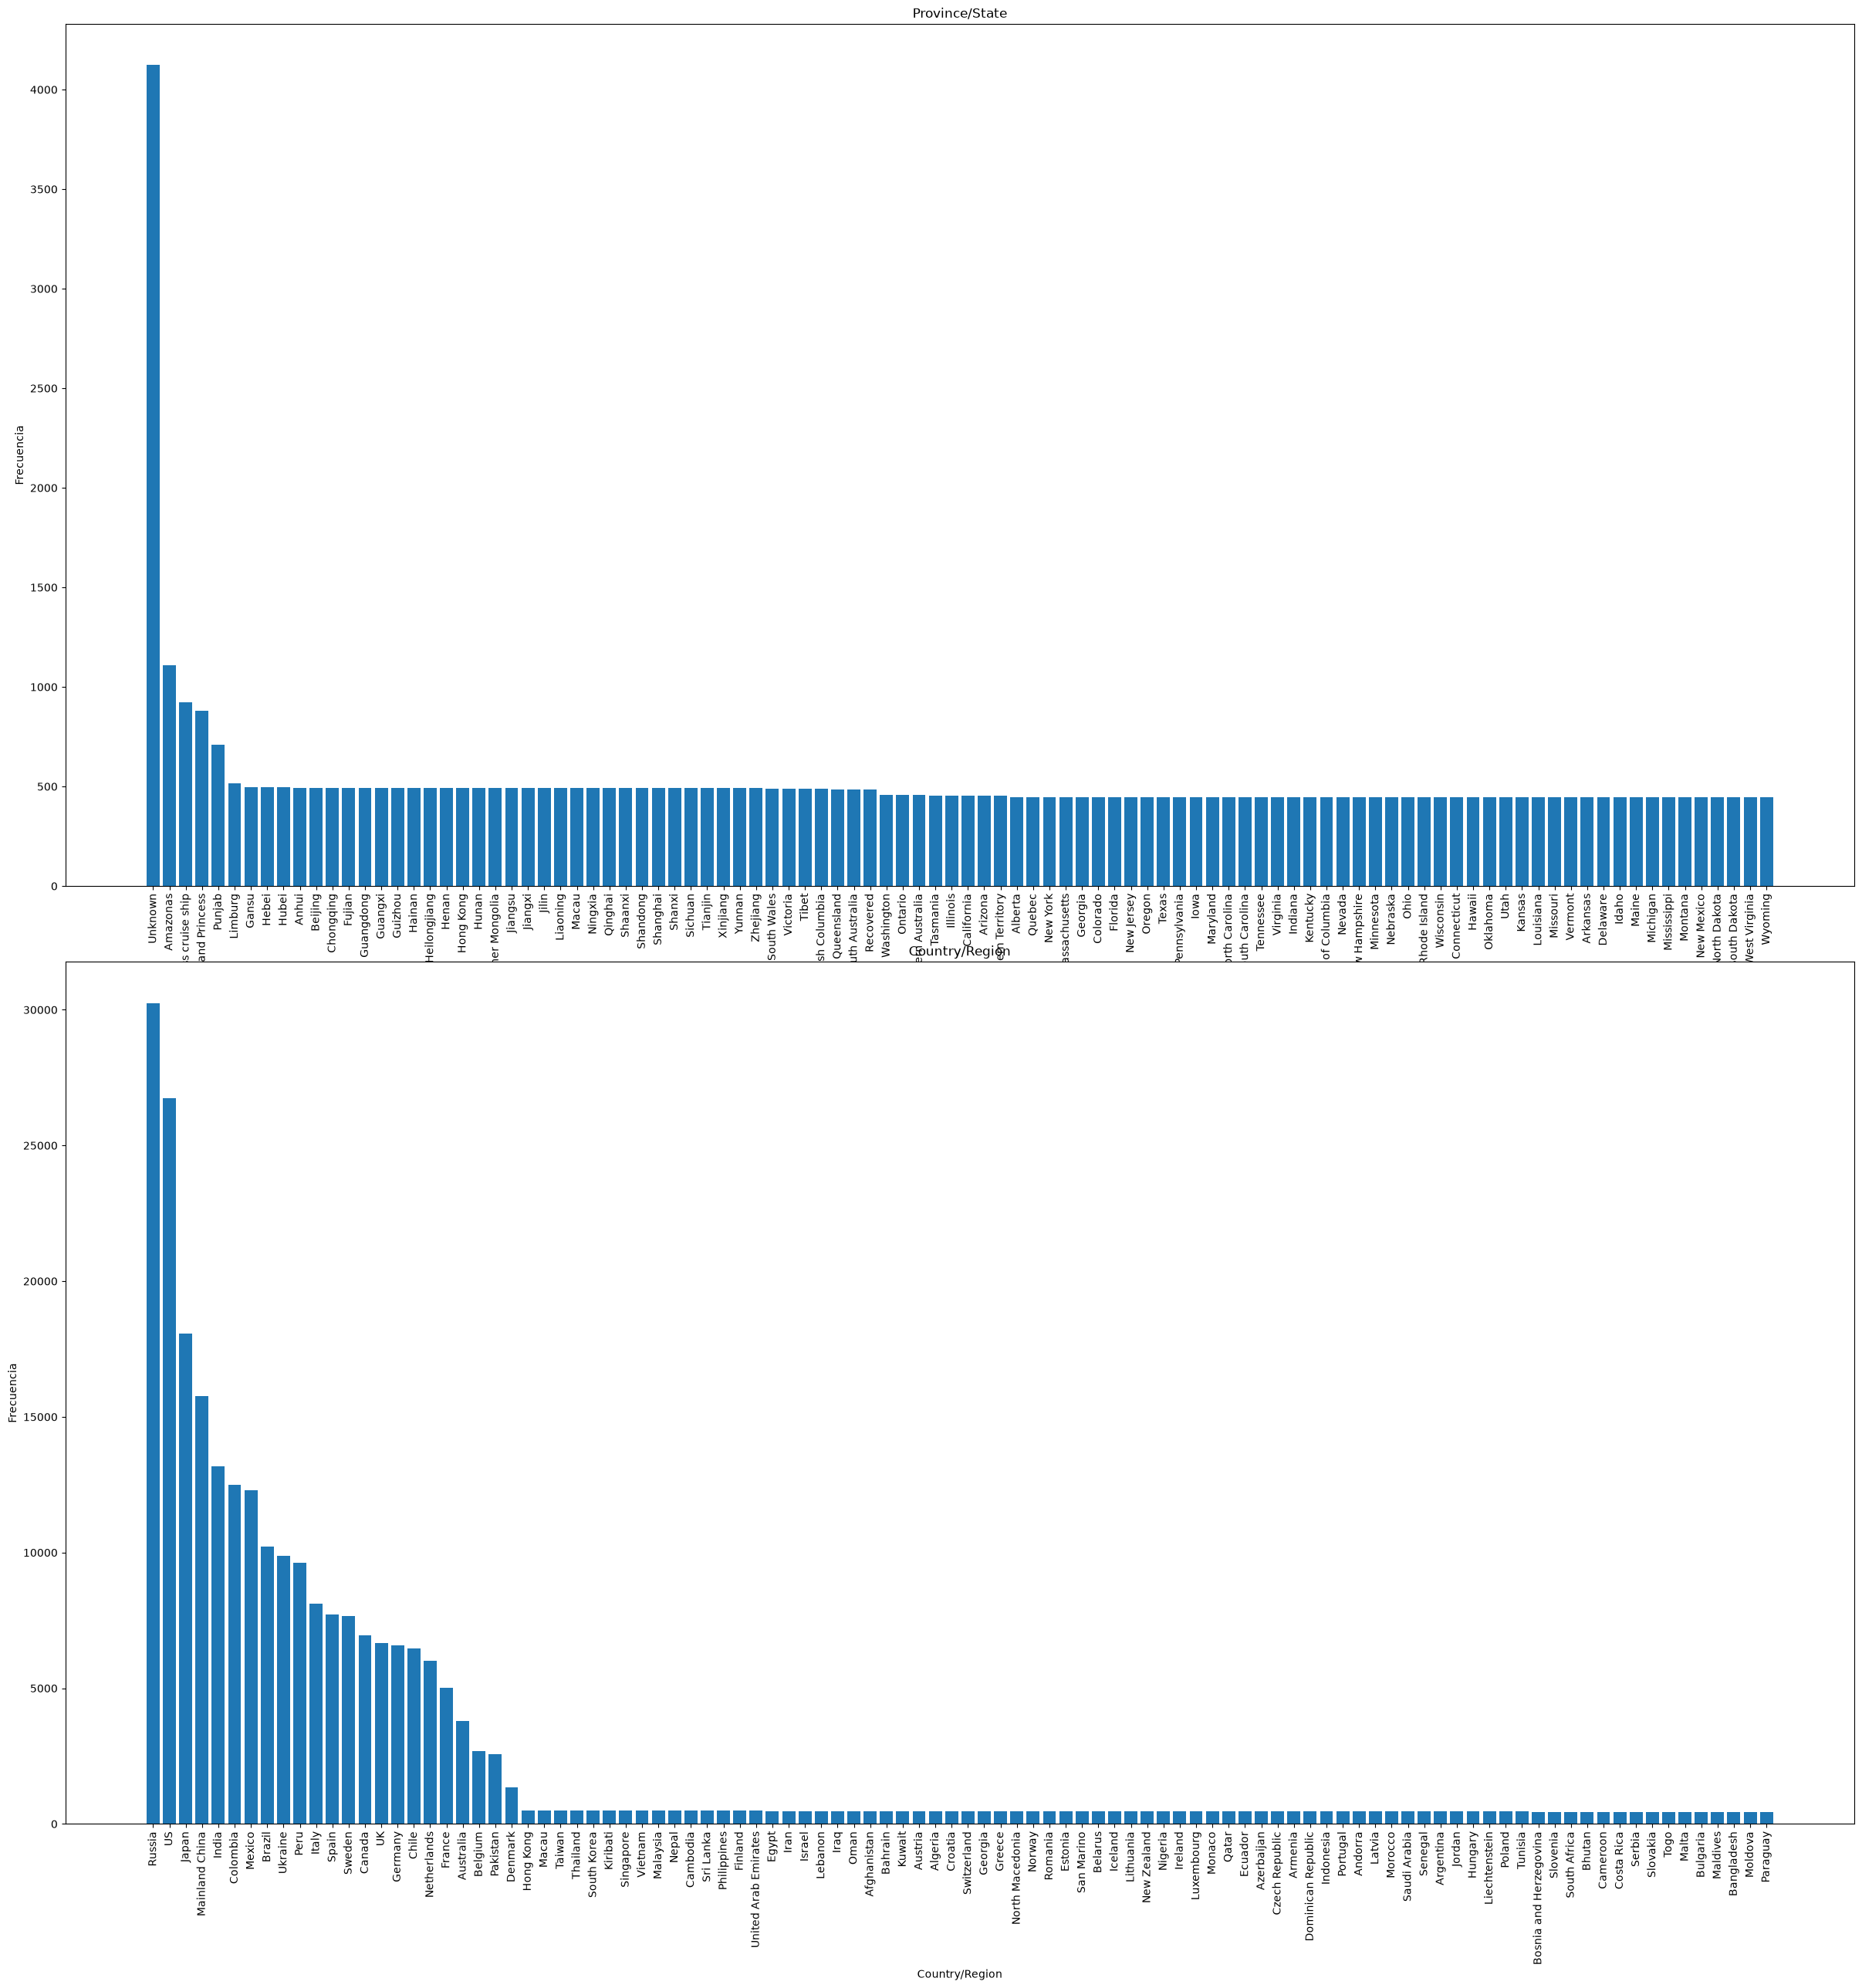

In [69]:
fig, ax = plt.subplots(nrows = len(categories), ncols = 1, figsize=(25, 25))
fig.subplots_adjust(hspace = 5)
plt.tight_layout(pad=5.0)        # Luego ajuste automático con padding extra

for i in range(len(categories)):
  curr_data = df[categories[i]].value_counts()
  most_frequent_values = curr_data.head(100)
  ax[i].bar(most_frequent_values.index, most_frequent_values.values)
  ax[i].set_title(categories[i])
  ax[i].set_xlabel(categories[i])
  ax[i].set_ylabel("Frecuencia")
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)

## 5.2. Analisis Generalizado Aplicable a Cualquier Tabla

In [70]:
def get_valid_categories(dfx):
  categories = list(dfx.select_dtypes(include=['object']).keys())
  categories = list(filter(lambda cat: not re.match(r"^\d{2}/\d{2}/\d{2}$", cat), categories))
  aux = []
  for category in categories:
    valid_category = not any(map(lambda val: bool(re.match(r"^\d{1,2}/\d{1,2}/", str(val))),
        dfx[category][dfx[category].apply(lambda x: not isinstance(x, (float, int)))]))
    if valid_category:
        aux.append(category)
  categories = aux
  return categories

In [71]:
def categorical_consistency_analysis(dfx):
  print("Analisis de valores mas comunes en cada columna categorica", '\n')
  categories = get_valid_categories(dfx)
  print("Categorias de la tabla", categories, '\n')
  print("Columnas Categoricas en la tabla:", categories)
  if len(categories) == 0:
    print("No hay columnas de texto en esta tabla.")
  else:
    for col in categories:
      unique_values = dfx[col].nunique()
      print(f"\nColumna: '{col}' | Valores unicos: {unique_values}")
      if unique_values > 0:
        print("Top 5 valores mas comunes (para revisar inconsistencias):")
        print(dfx[col].value_counts().head(50).to_string())

In [72]:
categorical_consistency_analysis(df6_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['Province/State', 'Country/Region'] 

Columnas Categoricas en la tabla: ['Province/State', 'Country/Region']

Columna: 'Province/State' | Valores unicos: 70
Top 5 valores mas comunes (para revisar inconsistencias):
Province/State
Unknown                         191
Australian Capital Territory      1
New South Wales                   1
Northern Territory                1
Queensland                        1
South Australia                   1
Tasmania                          1
Victoria                          1
Western Australia                 1
Anhui                             1
Beijing                           1
Chongqing                         1
Fujian                            1
Gansu                             1
Guangdong                         1
Guangxi                           1
Guizhou                           1
Hainan                            1
Hebei                             1
H

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


## 5.3. Limpieza de Datos

Una vez concretado el analisis y vista mediante diagramas de valores con diferentes representaciones tipograficas se puede determinar puntualmente que valores para ciertas columnas pueden estandarizarse en una sola denominacion (ejemplo Bolivia, bolivia, bol, BOL).

Ademas de ello tambien por cada tabla se realizara una normalizacion de los valores categoricos no numericos, para contemplar un formato comun como no tener capitalizacion, control de numeros, etc.



### 5.3.1. Normalizacion de Valores en Todas las Tablas:

Primero se obtienen las categorias no numericas validas analizadas anteriormente para aplicar las siguientes operaciones:
- **Espacios a los extremos:** se quitan los espacios iniciales del inicio y fin de las cadenas o valores categoricos con ayuda del uso del metodo strip().
- **Minusculas:** para una mejor estandarizacion todos los caracteres de los valores se normalizan solo a minusculas.
- **Espacios Sobrantes:** se quitan espacios extra en cualquier parte del texto con replace() y expreciones regulares con regex.

Todas estas pueden ser encapsuladas en la funcion *normalize_df()* como se ve a continuacion:

In [73]:
def normalize_df(dfx_):
  categories = get_valid_categories(dfx_)
  print("Categorias de la tabla", categories, '\n')

  for category in categories:
    dfx_[category] = dfx_[category].str.strip()
    dfx_[category] = dfx_[category].str.lower()
    dfx_[category] = dfx_[category].str.replace(r"\s", " ", regex=True)
  print("Tabla de Datos Generales Normalizada:")
  print(dfx_)

In [74]:
# Normalizacion de la Tabla de Datos Generales:
normalize_df(df1_)

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


Categorias de la tabla ['Province/State', 'Country/Region'] 

Tabla de Datos Generales Normalizada:
           SNo ObservationDate     Province/State  Country/Region  \
0            1      01/22/2020              anhui  mainland china   
1            2      01/22/2020            beijing  mainland china   
2            3      01/22/2020          chongqing  mainland china   
3            4      01/22/2020             fujian  mainland china   
4            5      01/22/2020              gansu  mainland china   
...        ...             ...                ...             ...   
306424  306425      05/29/2021  zaporizhia oblast         ukraine   
306425  306426      05/29/2021            zeeland     netherlands   
306426  306427      05/29/2021           zhejiang  mainland china   
306427  306428      05/29/2021    zhytomyr oblast         ukraine   
306428  306429      05/29/2021       zuid-holland     netherlands   

                Last Update  Confirmed  Deaths  Recovered  
0          

In [75]:
# Normalizacion de la Tabla de Casos Confirmados:
normalize_df(df2_)

Categorias de la tabla ['Province/State', 'Country/Region'] 

Tabla de Datos Generales Normalizada:
    Province/State      Country/Region        Lat        Long  1/22/20  \
0          unknown         afghanistan  33.939110   67.709953        0   
1          unknown             albania  41.153300   20.168300        0   
2          unknown             algeria  28.033900    1.659600        0   
3          unknown             andorra  42.506300    1.521800        0   
4          unknown              angola -11.202700   17.873900        0   
..             ...                 ...        ...         ...      ...   
271        unknown             vietnam  14.058324  108.277199        0   
272        unknown  west bank and gaza  31.952200   35.233200        0   
273        unknown               yemen  15.552727   48.516388        0   
274        unknown              zambia -13.133897   27.849332        0   
275        unknown            zimbabwe -19.015438   29.154857        0   

     1/23/2

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [76]:
# Normalizacion de la Tabla de Casos Confirmados en USA:
normalize_df(df3_)

Categorias de la tabla ['iso2', 'iso3', 'Admin2', 'Province_State'] 

Tabla de Datos Generales Normalizada:
           UID iso2 iso3  code3   FIPS      Admin2 Province_State        Lat  \
0     84001001   us  usa    840   1001     autauga        alabama  32.539527   
1     84001003   us  usa    840   1003     baldwin        alabama  30.727750   
2     84001005   us  usa    840   1005     barbour        alabama  31.868263   
3     84001007   us  usa    840   1007        bibb        alabama  32.996421   
4     84001009   us  usa    840   1009      blount        alabama  33.982109   
...        ...  ...  ...    ...    ...         ...            ...        ...   
3337  84056039   us  usa    840  56039       teton        wyoming  43.935225   
3338  84056041   us  usa    840  56041       uinta        wyoming  41.287818   
3339  84090056   us  usa    840  90056  unassigned        wyoming   0.000000   
3340  84056043   us  usa    840  56043    washakie        wyoming  43.904516   
3341  840560

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [77]:
# Normalizacion de la Tabla de Decesos:
normalize_df(df4_)

Categorias de la tabla ['Province/State', 'Country/Region'] 

Tabla de Datos Generales Normalizada:
    Province/State      Country/Region        Lat        Long  1/22/20  \
0          unknown         afghanistan  33.939110   67.709953        0   
1          unknown             albania  41.153300   20.168300        0   
2          unknown             algeria  28.033900    1.659600        0   
3          unknown             andorra  42.506300    1.521800        0   
4          unknown              angola -11.202700   17.873900        0   
..             ...                 ...        ...         ...      ...   
271        unknown             vietnam  14.058324  108.277199        0   
272        unknown  west bank and gaza  31.952200   35.233200        0   
273        unknown               yemen  15.552727   48.516388        0   
274        unknown              zambia -13.133897   27.849332        0   
275        unknown            zimbabwe -19.015438   29.154857        0   

     1/23/2

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [78]:
# Normalizacion de la Tabla de Decesos en USA:
normalize_df(df5_)

Categorias de la tabla ['iso2', 'iso3', 'Admin2', 'Province_State'] 

Tabla de Datos Generales Normalizada:
           UID iso2 iso3  code3   FIPS      Admin2 Province_State        Lat  \
0     84001001   us  usa    840   1001     autauga        alabama  32.539527   
1     84001003   us  usa    840   1003     baldwin        alabama  30.727750   
2     84001005   us  usa    840   1005     barbour        alabama  31.868263   
3     84001007   us  usa    840   1007        bibb        alabama  32.996421   
4     84001009   us  usa    840   1009      blount        alabama  33.982109   
...        ...  ...  ...    ...    ...         ...            ...        ...   
3337  84056039   us  usa    840  56039       teton        wyoming  43.935225   
3338  84056041   us  usa    840  56041       uinta        wyoming  41.287818   
3339  84090056   us  usa    840  90056  unassigned        wyoming   0.000000   
3340  84056043   us  usa    840  56043    washakie        wyoming  43.904516   
3341  840560

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [79]:
# Normalizacion de la Tabla de Pacientes Recuperados:
normalize_df(df6_)

Categorias de la tabla ['Province/State', 'Country/Region'] 

Tabla de Datos Generales Normalizada:
    Province/State      Country/Region        Lat        Long  1/22/20  \
0          unknown         afghanistan  33.939110   67.709953        0   
1          unknown             albania  41.153300   20.168300        0   
2          unknown             algeria  28.033900    1.659600        0   
3          unknown             andorra  42.506300    1.521800        0   
4          unknown              angola -11.202700   17.873900        0   
..             ...                 ...        ...         ...      ...   
256        unknown             vietnam  14.058324  108.277199        0   
257        unknown  west bank and gaza  31.952200   35.233200        0   
258        unknown               yemen  15.552727   48.516388        0   
259        unknown              zambia -13.133897   27.849332        0   
260        unknown            zimbabwe -19.015438   29.154857        0   

     1/23/2

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


### 5.3.2. Unificacion de Representaciones Variadas de Valores
Como se ha mencionado en la parte del analisis, en esta primera iteracion de la limpieza de datos resulta complejo hacer la unificacion de reresentaciones variadas de valores categoricos, por lo que se ha optado por analizar los 50 valores mas frecuentes de cada categoria para cada tabla.

*Para esta parte se concideran las mismas categorias que en la normalizacion.*

****Analisis de las 6 Tablas:****
- **Tablas de Datos Generales, Casos Confirmados, Decesos y Recuperados** Para el caso de estas tablas tanto el atributo **Province/State** y el atributo **Country/Region** que aparecen coincidentemente no cuentan con representaciones variadas ni ambiguas en sus valores, por lo que no es necesario unificar nada en ellas, como aclaracion, pese a ser atributos iguales sus valores no son necesariamente iguales.
- **Tablas de Casos Confirmados y Decesos en USA:** coinciden las categorias **iso2, iso3, Admin2, Province_State, Country_Region** y **Combined_Key**, sin embargo ninguna de ellas cuentan con representaciones variadas de valores puntuales, no necesitan de unificacion.

Esta conclusion se obtiene de observar pausadamente la recopilacion de valores unicos por cada categoria con el metodo *categorical_consistency_analysis()*.

In [80]:
# Analisis de Representaciones Variadas para la Tabla de Datos Generales:
categorical_consistency_analysis(df1_)

Analisis de valores mas comunes en cada columna categorica 



/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


Categorias de la tabla ['Province/State', 'Country/Region'] 

Columnas Categoricas en la tabla: ['Province/State', 'Country/Region']

Columna: 'Province/State' | Valores unicos: 735
Top 5 valores mas comunes (para revisar inconsistencias):
Province/State
unknown                         82226
amazonas                         1109
diamond princess cruise ship      924
grand princess                    882
punjab                            708
limburg                           516
gansu                             496
hebei                             495
hubei                             495
anhui                             494
beijing                           494
chongqing                         494
fujian                            494
guangdong                         494
guangxi                           494
guizhou                           494
hainan                            494
heilongjiang                      494
henan                             494
hong kong              

In [81]:
# Analisis de Representaciones Variadas para la Tabla de Datos de Casos Confirmados:
categorical_consistency_analysis(df2_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['Province/State', 'Country/Region'] 

Columnas Categoricas en la tabla: ['Province/State', 'Country/Region']

Columna: 'Province/State' | Valores unicos: 85
Top 5 valores mas comunes (para revisar inconsistencias):
Province/State
unknown                         190
australian capital territory      1
new south wales                   1
northern territory                1
queensland                        1
south australia                   1
tasmania                          1
victoria                          1
western australia                 1
alberta                           1
british columbia                  1
diamond princess                  1
grand princess                    1
manitoba                          1
new brunswick                     1
newfoundland and labrador         1
northwest territories             1
nova scotia                       1
nunavut                           1
o

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [82]:
# Analisis de Representaciones Variadas para la Tabla de Datos de Casos Confirmados en USA:
categorical_consistency_analysis(df3_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['iso2', 'iso3', 'Admin2', 'Province_State'] 

Columnas Categoricas en la tabla: ['iso2', 'iso3', 'Admin2', 'Province_State']

Columna: 'iso2' | Valores unicos: 6
Top 5 valores mas comunes (para revisar inconsistencias):
iso2
us    3248
pr      80
as       1
gu       1
mp       1
vi       1

Columna: 'iso3' | Valores unicos: 6
Top 5 valores mas comunes (para revisar inconsistencias):
iso3
usa    3248
pri      80
asm       1
gum       1
mnp       1
vir       1

Columna: 'Admin2' | Valores unicos: 1970
Top 5 valores mas comunes (para revisar inconsistencias):
Admin2
unassigned    58
washington    31
jefferson     26
franklin      25
jackson       24
lincoln       24
madison       20
clay          18
montgomery    18
union         18
marion        17
monroe        17
wayne         16
grant         15
greene        14
warren        14
carroll       13
lee           12
marshall      12
clark         12
johns

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [83]:
# Analisis de Representaciones Variadas para la Tabla de Datos de Decesos:
categorical_consistency_analysis(df4_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['Province/State', 'Country/Region'] 

Columnas Categoricas en la tabla: ['Province/State', 'Country/Region']

Columna: 'Province/State' | Valores unicos: 85
Top 5 valores mas comunes (para revisar inconsistencias):
Province/State
unknown                         190
australian capital territory      1
new south wales                   1
northern territory                1
queensland                        1
south australia                   1
tasmania                          1
victoria                          1
western australia                 1
alberta                           1
british columbia                  1
diamond princess                  1
grand princess                    1
manitoba                          1
new brunswick                     1
newfoundland and labrador         1
northwest territories             1
nova scotia                       1
nunavut                           1
o

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [84]:
# Analisis de Representaciones Variadas para la Tabla de Datos de Decesos en USA:
categorical_consistency_analysis(df5_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['iso2', 'iso3', 'Admin2', 'Province_State'] 

Columnas Categoricas en la tabla: ['iso2', 'iso3', 'Admin2', 'Province_State']

Columna: 'iso2' | Valores unicos: 6
Top 5 valores mas comunes (para revisar inconsistencias):
iso2
us    3248
pr      80
as       1
gu       1
mp       1
vi       1

Columna: 'iso3' | Valores unicos: 6
Top 5 valores mas comunes (para revisar inconsistencias):
iso3
usa    3248
pri      80
asm       1
gum       1
mnp       1
vir       1

Columna: 'Admin2' | Valores unicos: 1970
Top 5 valores mas comunes (para revisar inconsistencias):
Admin2
unassigned    58
washington    31
jefferson     26
franklin      25
jackson       24
lincoln       24
madison       20
clay          18
montgomery    18
union         18
marion        17
monroe        17
wayne         16
grant         15
greene        14
warren        14
carroll       13
lee           12
marshall      12
clark         12
johns

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


In [85]:
# Analisis de Representaciones Variadas para la Tabla de Pacientes Recuperados:
categorical_consistency_analysis(df6_)

Analisis de valores mas comunes en cada columna categorica 

Categorias de la tabla ['Province/State', 'Country/Region'] 

Columnas Categoricas en la tabla: ['Province/State', 'Country/Region']

Columna: 'Province/State' | Valores unicos: 70
Top 5 valores mas comunes (para revisar inconsistencias):
Province/State
unknown                         191
australian capital territory      1
new south wales                   1
northern territory                1
queensland                        1
south australia                   1
tasmania                          1
victoria                          1
western australia                 1
anhui                             1
beijing                           1
chongqing                         1
fujian                            1
gansu                             1
guangdong                         1
guangxi                           1
guizhou                           1
hainan                            1
hebei                             1
h

/tmp/ipykernel_22137/903535119.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categories = list(dfx.select_dtypes(include=['object']).keys())


# 6. Analisis de Valores Extremos Fuera de Rango

## 6.1. Analisis Detallado

In [86]:
numeric_categories = df.select_dtypes(include=['int64', 'float64']).keys()
df[numeric_categories]

,SNo,Confirmed,Deaths,Recovered
0,1,1.0,0.0,0.0
1,2,14.0,0.0,0.0
2,3,6.0,0.0,0.0
3,4,1.0,0.0,0.0
4,5,0.0,0.0,0.0
...,...,...,...,...
306424,306425,102641.0,2335.0,95289.0
306425,306426,29147.0,245.0,0.0
306426,306427,1364.0,1.0,1324.0
306427,306428,87550.0,1738.0,83790.0


In [87]:
numeric_categories = list(filter(lambda cat: not re.match(r"^\d{1,2}/\d{1,2}/", cat), numeric_categories))
df[numeric_categories]

,SNo,Confirmed,Deaths,Recovered
0,1,1.0,0.0,0.0
1,2,14.0,0.0,0.0
2,3,6.0,0.0,0.0
3,4,1.0,0.0,0.0
4,5,0.0,0.0,0.0
...,...,...,...,...
306424,306425,102641.0,2335.0,95289.0
306425,306426,29147.0,245.0,0.0
306426,306427,1364.0,1.0,1324.0
306427,306428,87550.0,1738.0,83790.0


In [88]:
numeric_categories = list(filter(lambda cat: (df[cat].nunique() < df.shape[0]), numeric_categories))
print("Categorias Numericas Relevantes:", '\n')
df[numeric_categories]

Categorias Numericas Relevantes: 



,Confirmed,Deaths,Recovered
0,1.0,0.0,0.0
1,14.0,0.0,0.0
2,6.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0
...,...,...,...
306424,102641.0,2335.0,95289.0
306425,29147.0,245.0,0.0
306426,1364.0,1.0,1324.0
306427,87550.0,1738.0,83790.0


/tmp/ipykernel_22137/3223000644.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/3223000644.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/3223000644.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


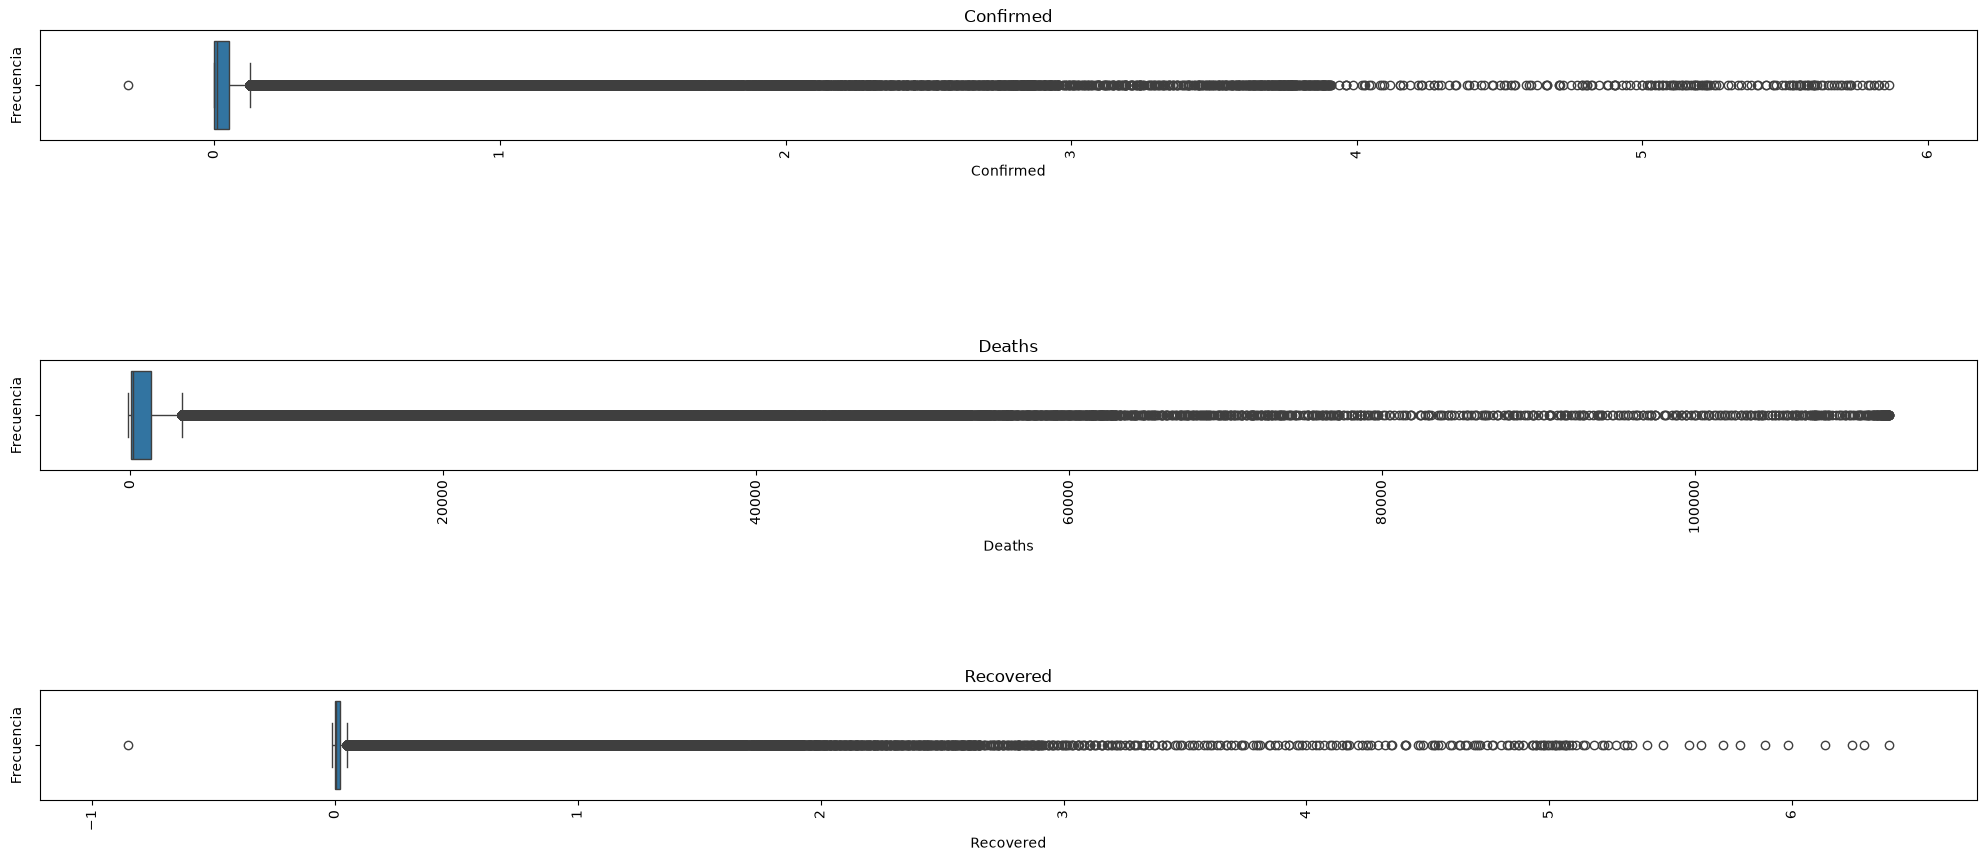

In [89]:
fig, ax = plt.subplots(nrows = len(numeric_categories), ncols = 1, figsize=(25, 10))
fig.subplots_adjust(hspace = 2)

for i in range(len(numeric_categories)):
  sns.boxplot(data=df, x=numeric_categories[i], ax=ax[i])
  ax[i].set_title(numeric_categories[i])
  ax[i].set_xlabel(numeric_categories[i])
  ax[i].set_ylabel("Frecuencia")
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)

## 6.2. Analisis Generalizado para Cualquier Tabla

In [90]:
def get_numeric_categories(dfx):
  numeric_categories = dfx.select_dtypes(include=['int64', 'float64']).keys()
  numeric_categories = list(filter(lambda cat: not re.match(r"^\d{1,2}/\d{1,2}/", cat), numeric_categories))
  numeric_categories = list(filter(lambda cat: (dfx[cat].nunique() < dfx.shape[0]), numeric_categories))
  return numeric_categories

In [91]:
def outlier_value_analysis(dfx):
  print("Analisis de valores fuera de rango en cada columna numerica de la tabla", '\n')
  numeric_categories = get_numeric_categories(dfx)
  print("Categorias Numericas Relevantes:", numeric_categories, '\n')
  if len(numeric_categories) == 0:
    print("No hay columnas numericas relevantes en esta tabla.")
  fig, ax = plt.subplots(nrows = len(numeric_categories), ncols = 1, figsize=(25, 10))
  fig.subplots_adjust(hspace = 2)
  for i in range(len(numeric_categories)):
    sns.boxplot(data=dfx, x=numeric_categories[i], ax=ax[i])
    ax[i].set_title(numeric_categories[i])
    ax[i].set_xlabel(numeric_categories[i])
    ax[i].set_ylabel("Frecuencia")
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)

## 6.3. Limpieza de Datos
En esta instancia, ya es posible generar un criterio respecto a la depuracion de valores numericos extremos maximos y minimos que pueden ser sospechosos y que pueden parecer que estan fuera de lo normal.

Este criterio se basa principalmente en el contexto del problema y la naturaleza de cada categoria de cada tabla del dataset como se vera a continuacion.

### 6.3.1. Tabla de Datos Globales

Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['Confirmed', 'Deaths', 'Recovered'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


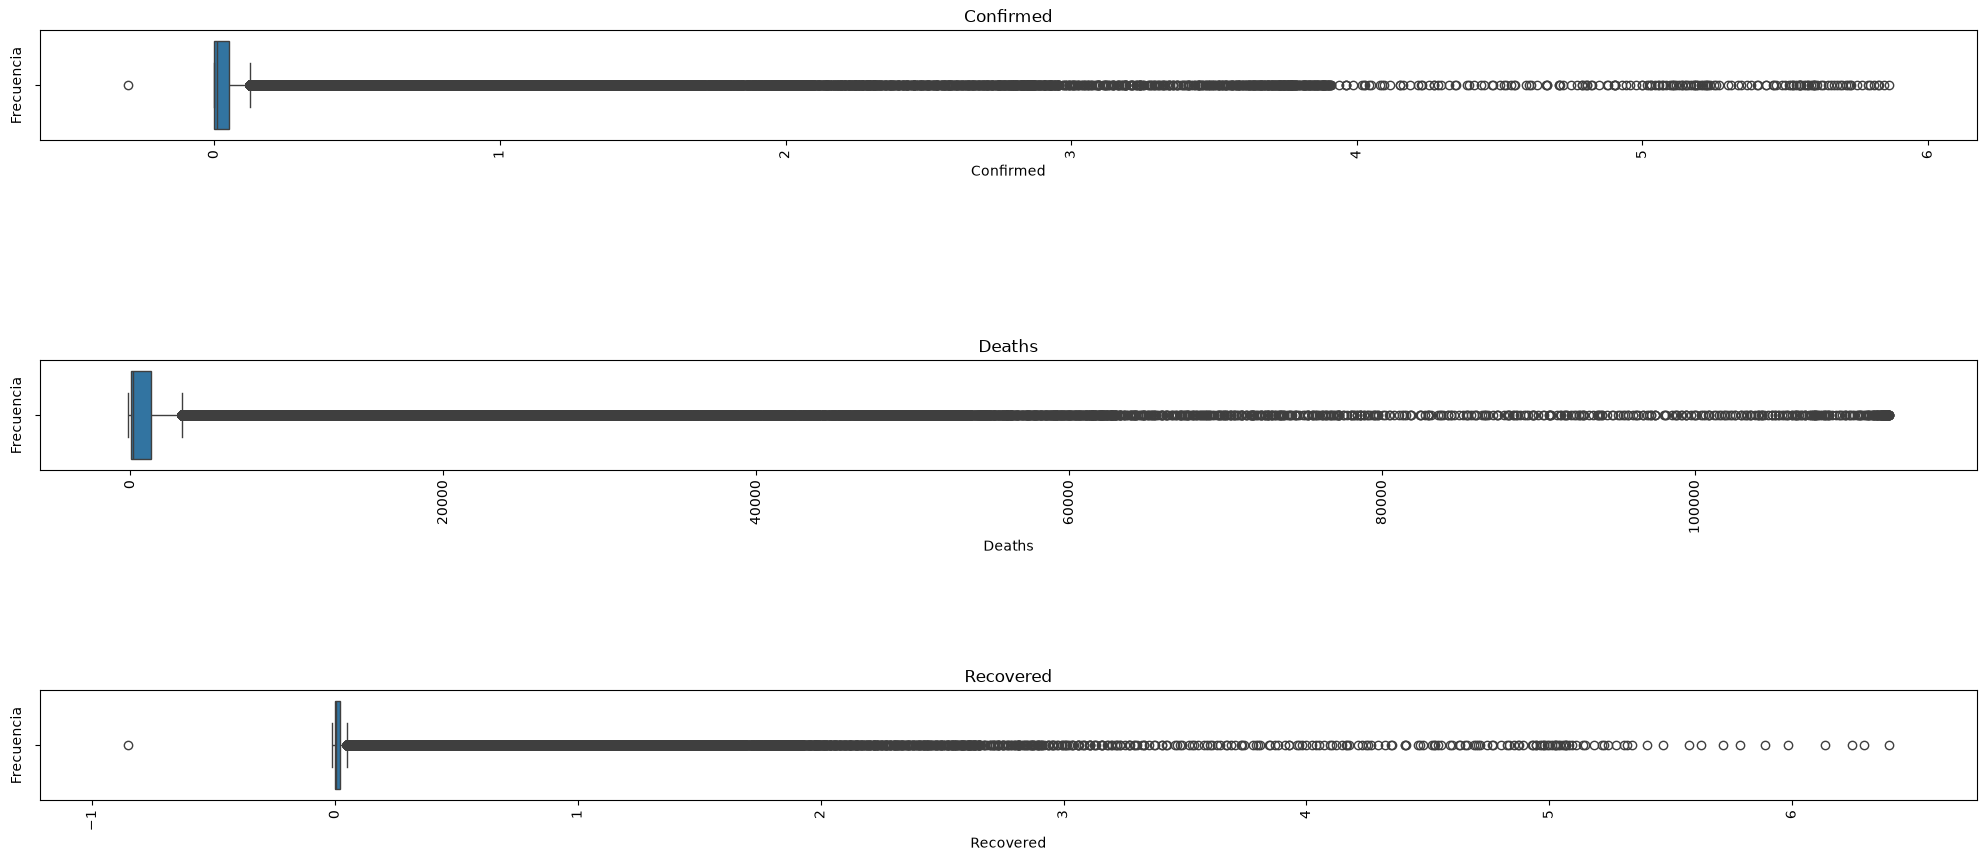

In [92]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Datos Generales
outlier_value_analysis(df1_)

- Como se observa en los diagramas de cajas y bigites, los valores se salen de forma excesiva de los limites naturales del rango inter quartil, esto se debe a que las categorias numericas **Confirmed, Deaths** y **Recovered** son de caracter acumulativo y dependientes de categorias como el lugar y el momento (dia), no se pueden descartar valores extremos

### 6.3.2. Tablas de Casos Confirmados, Decesos y Pacientes Recuperados

Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['Lat', 'Long'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


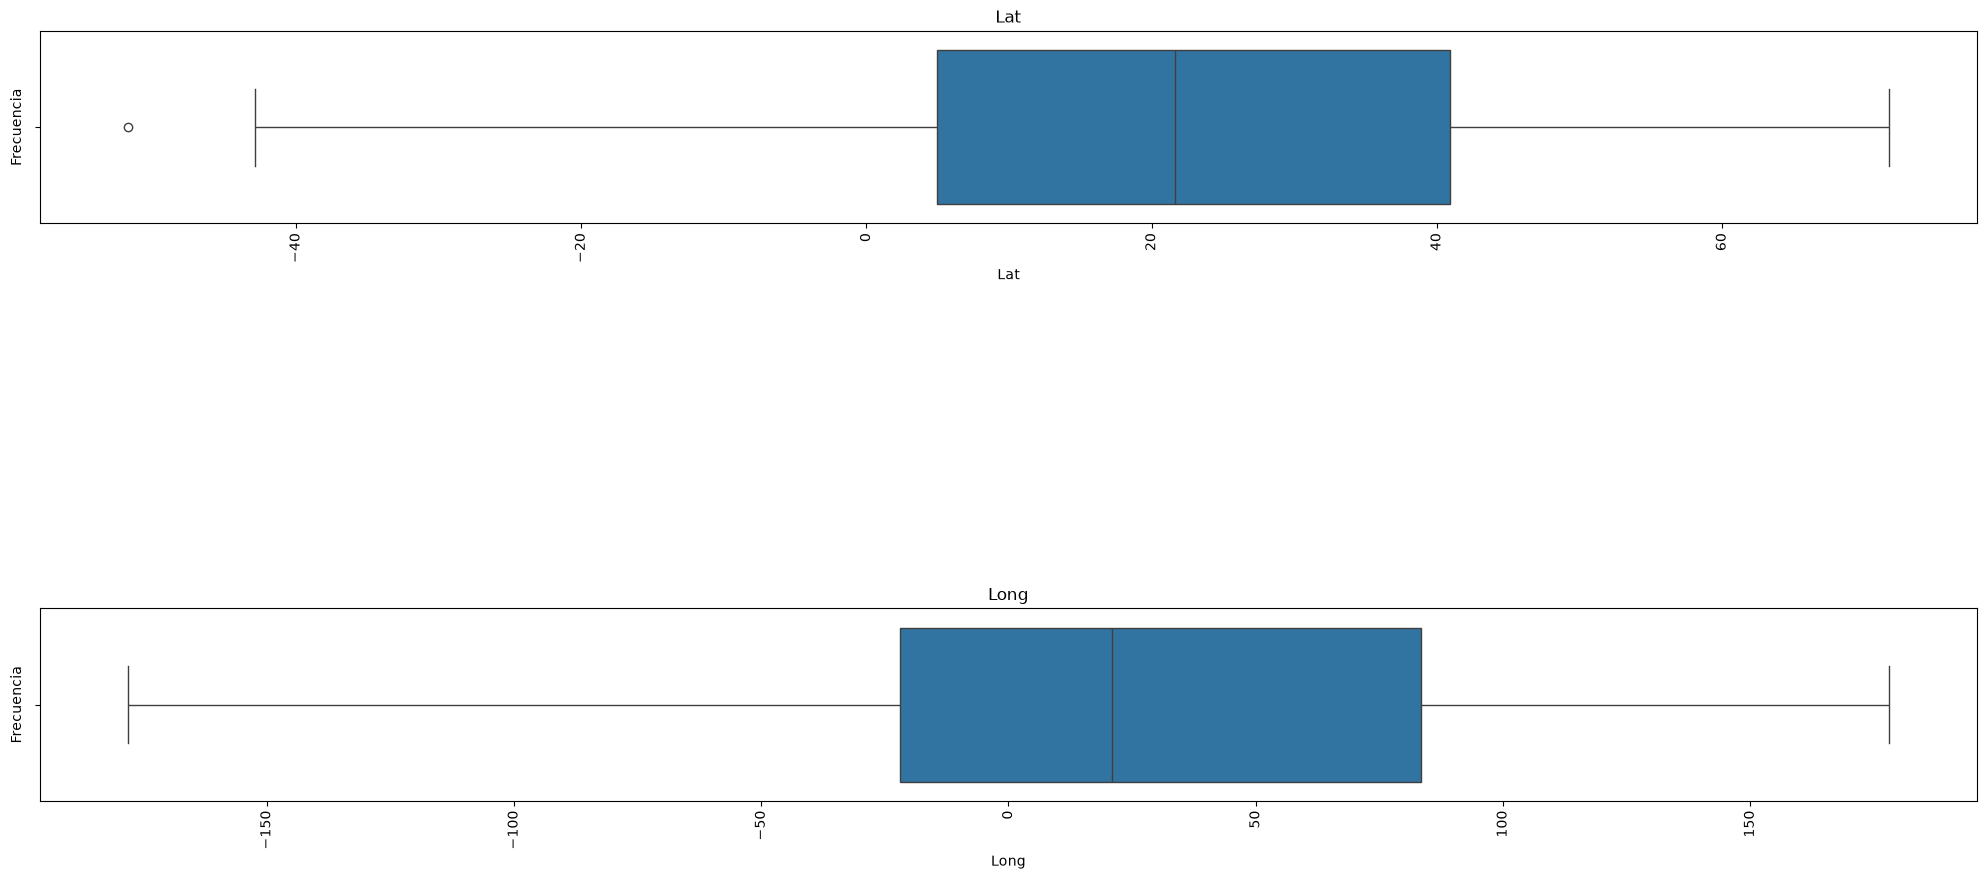

In [93]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Casos Confirmados:
outlier_value_analysis(df2_)

Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['Lat', 'Long'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


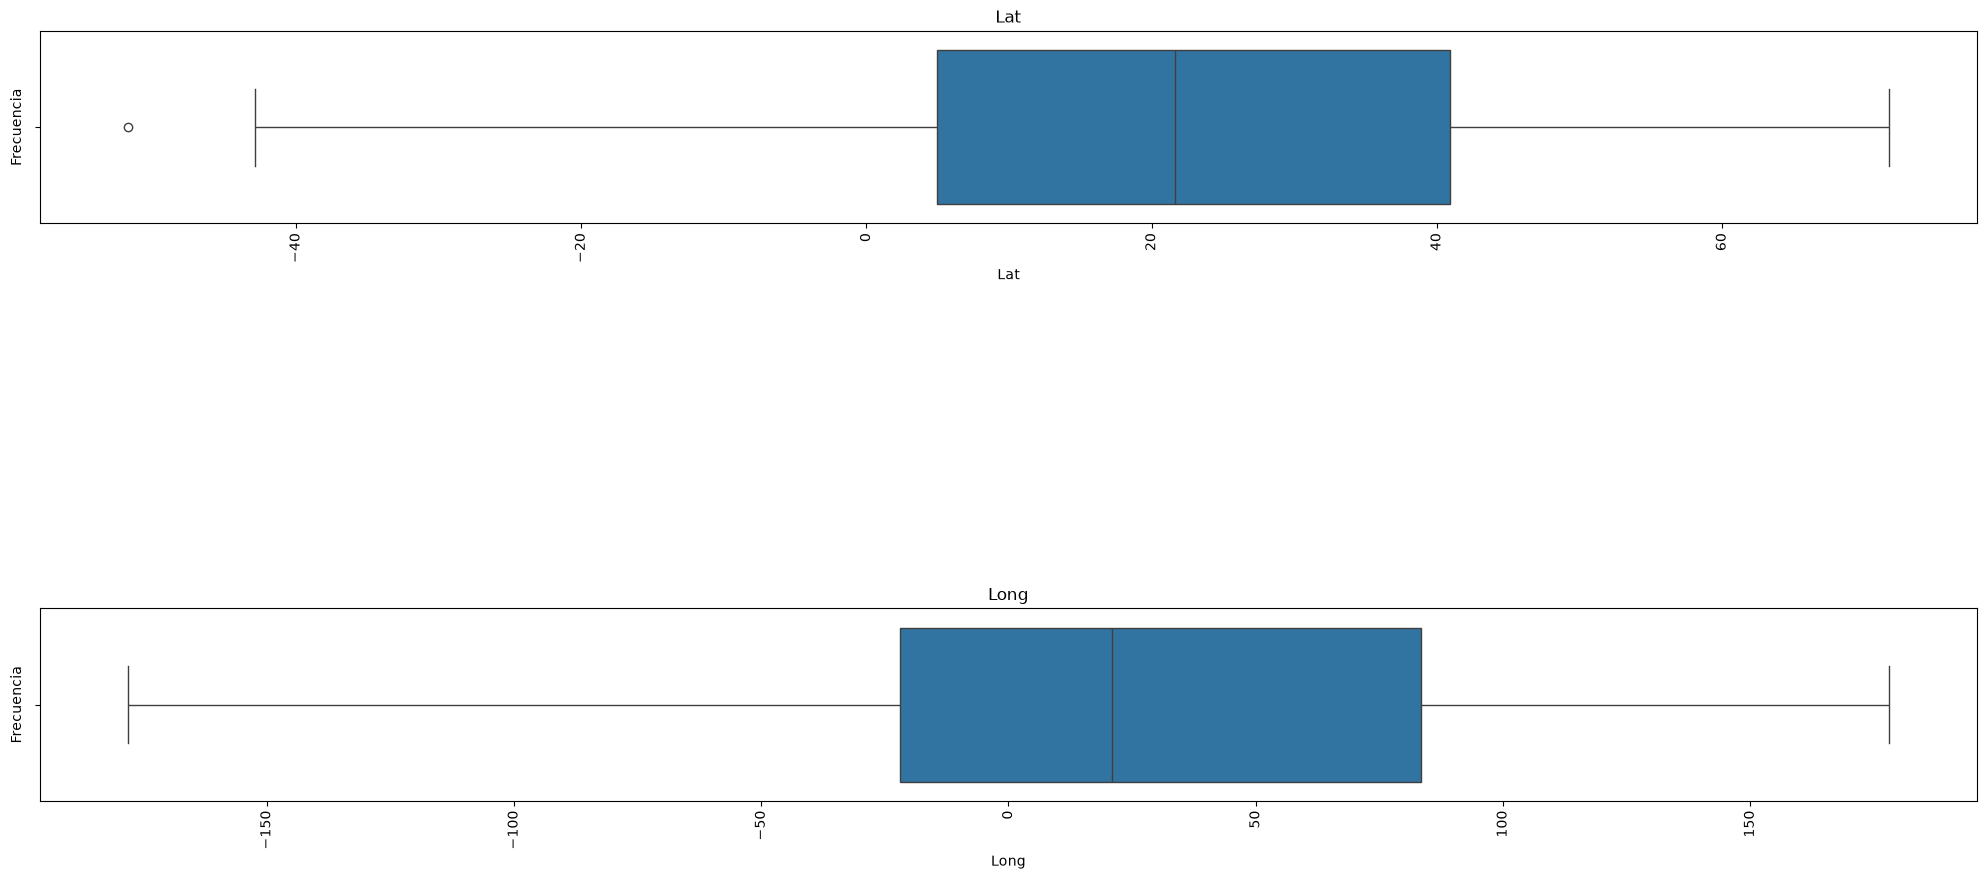

In [94]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Decesos:
outlier_value_analysis(df4_)

Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['Lat', 'Long'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


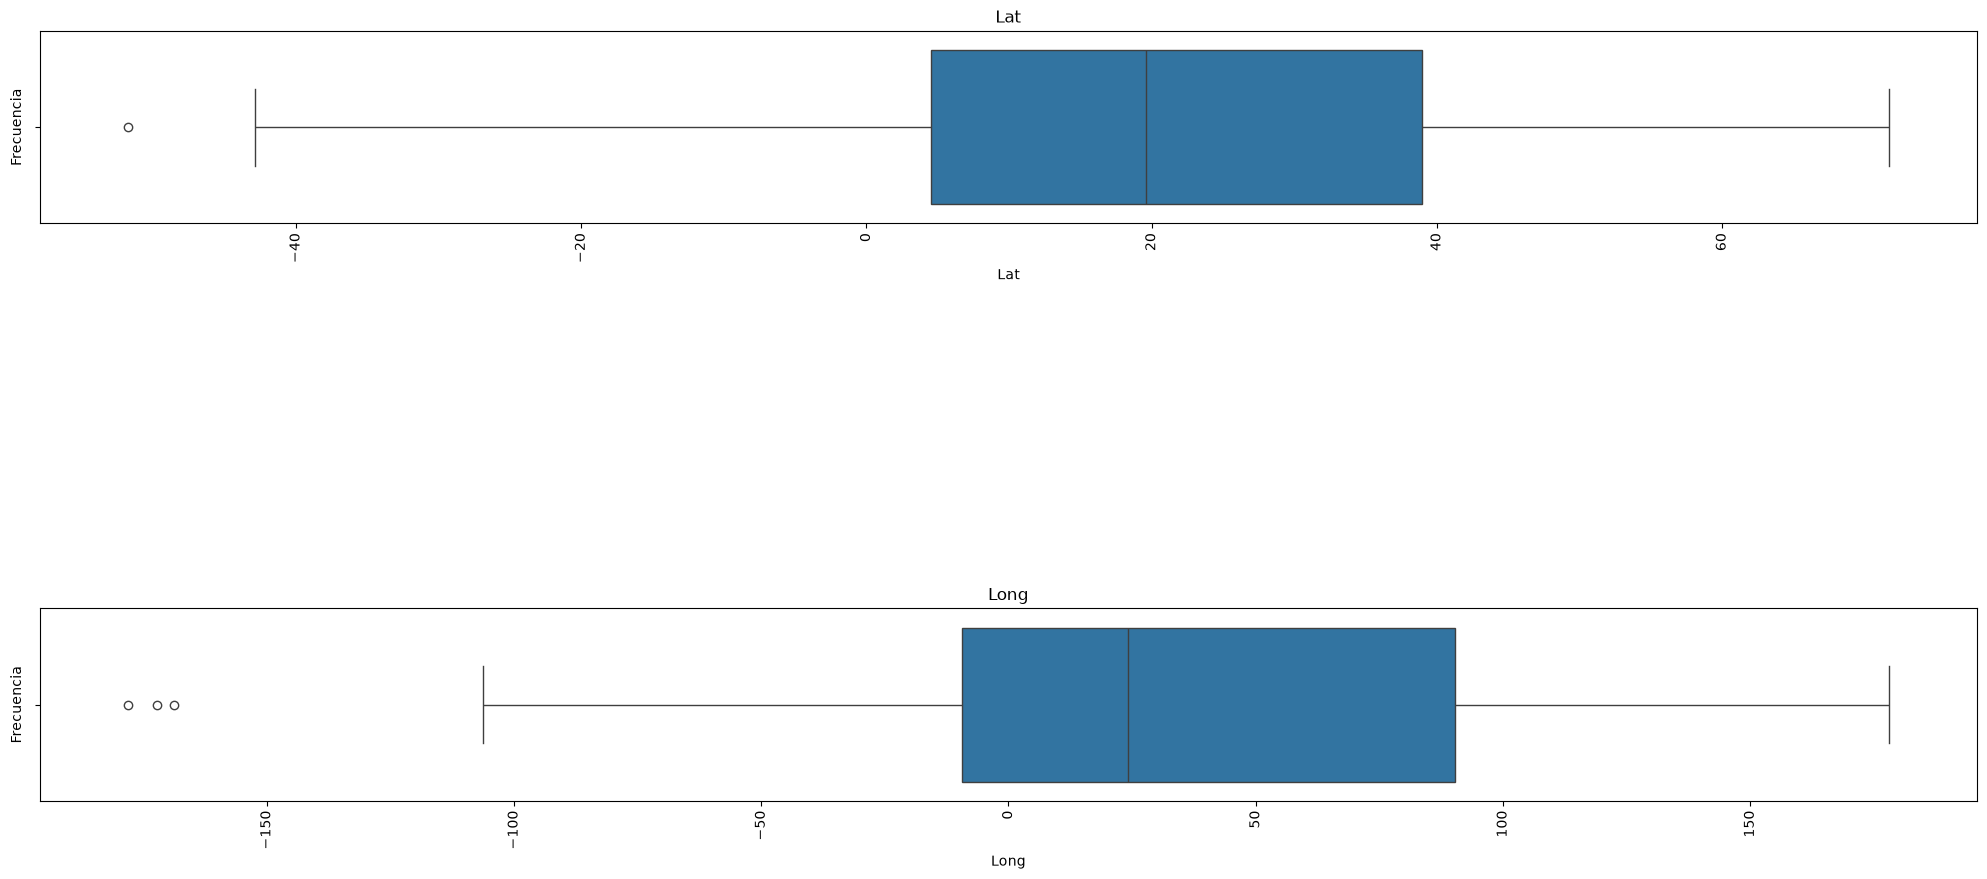

In [95]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Pacientes Recuperados:
outlier_value_analysis(df6_)

- Para el caso de estas tres tablas, resultan ser la latitud y longitud las categorias numericas mas propensas a tener rangos fuera de los limites comunes con valores maximos y minimos, sin embargoo en el fondo no son determinantes en el contexto de conteo de casos confirmados, decesos o recuperaciones acumuladas dia tras dia, por tanto no se modifican.

### 6.3.3. Tablas de Casos Confirmados y Decesos en USA

/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['code3', 'Lat', 'Long_'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)


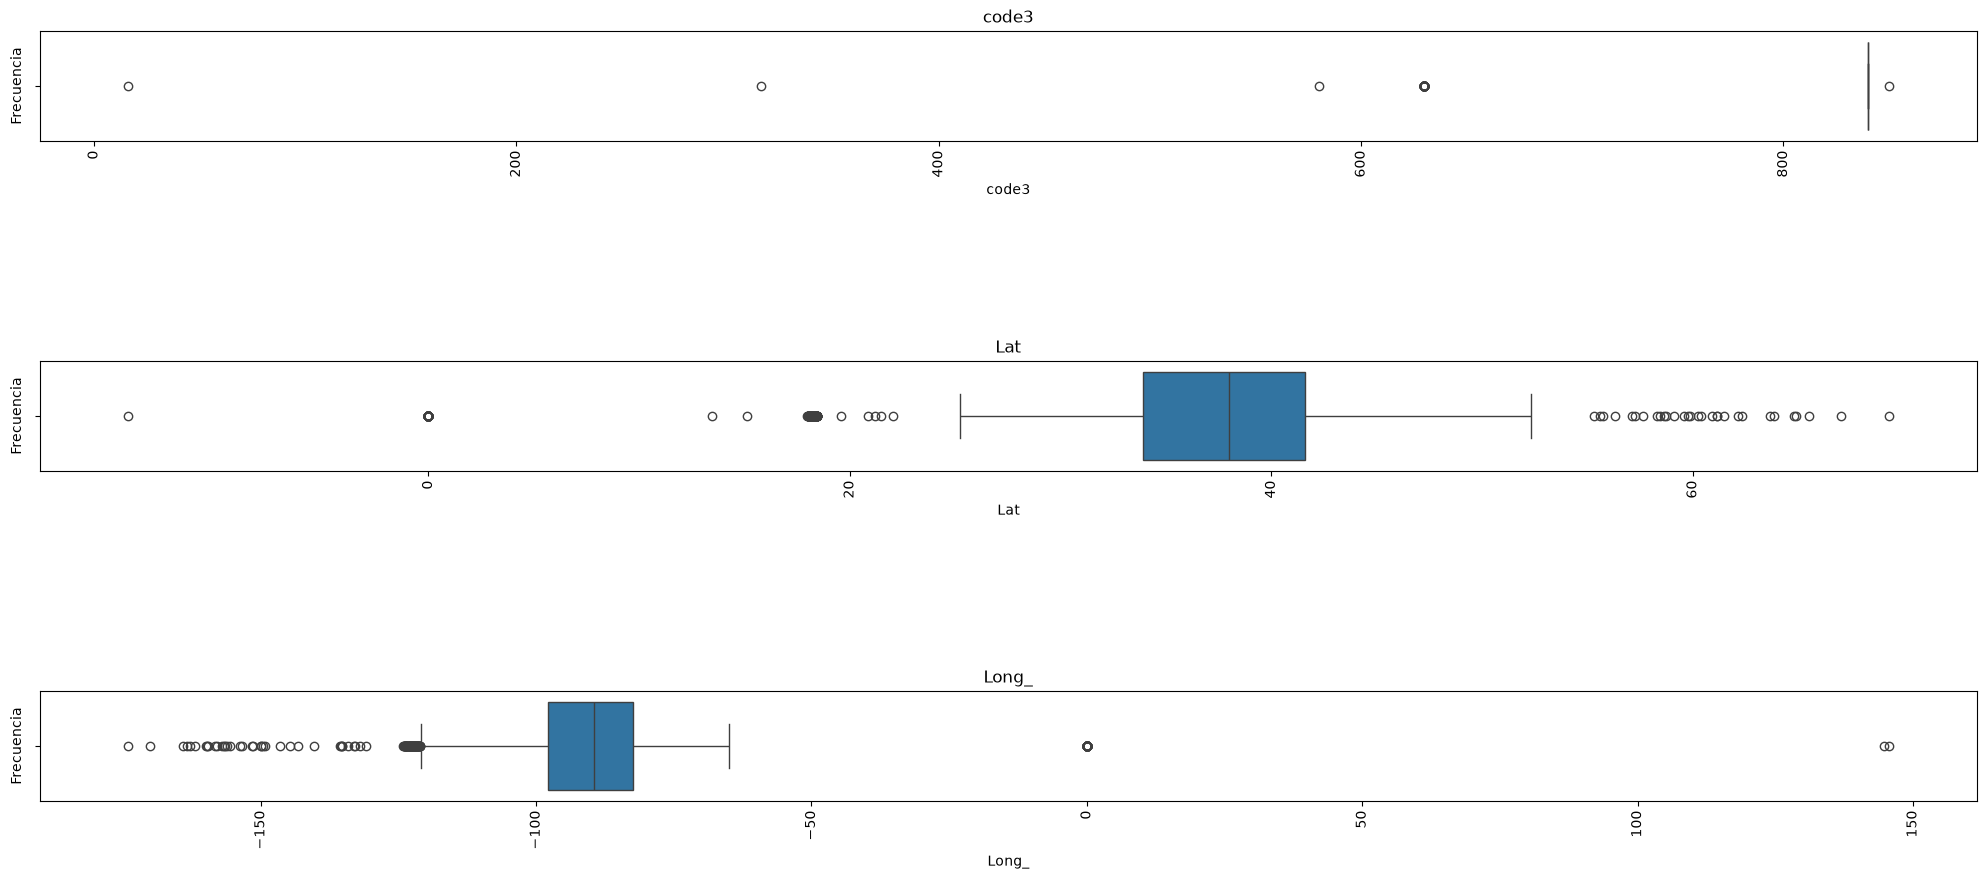

In [96]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Casos Confirmados en USA:
outlier_value_analysis(df3_)

Analisis de valores fuera de rango en cada columna numerica de la tabla 

Categorias Numericas Relevantes: ['code3', 'Lat', 'Long_', 'Population'] 



/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_22137/2387972307.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  

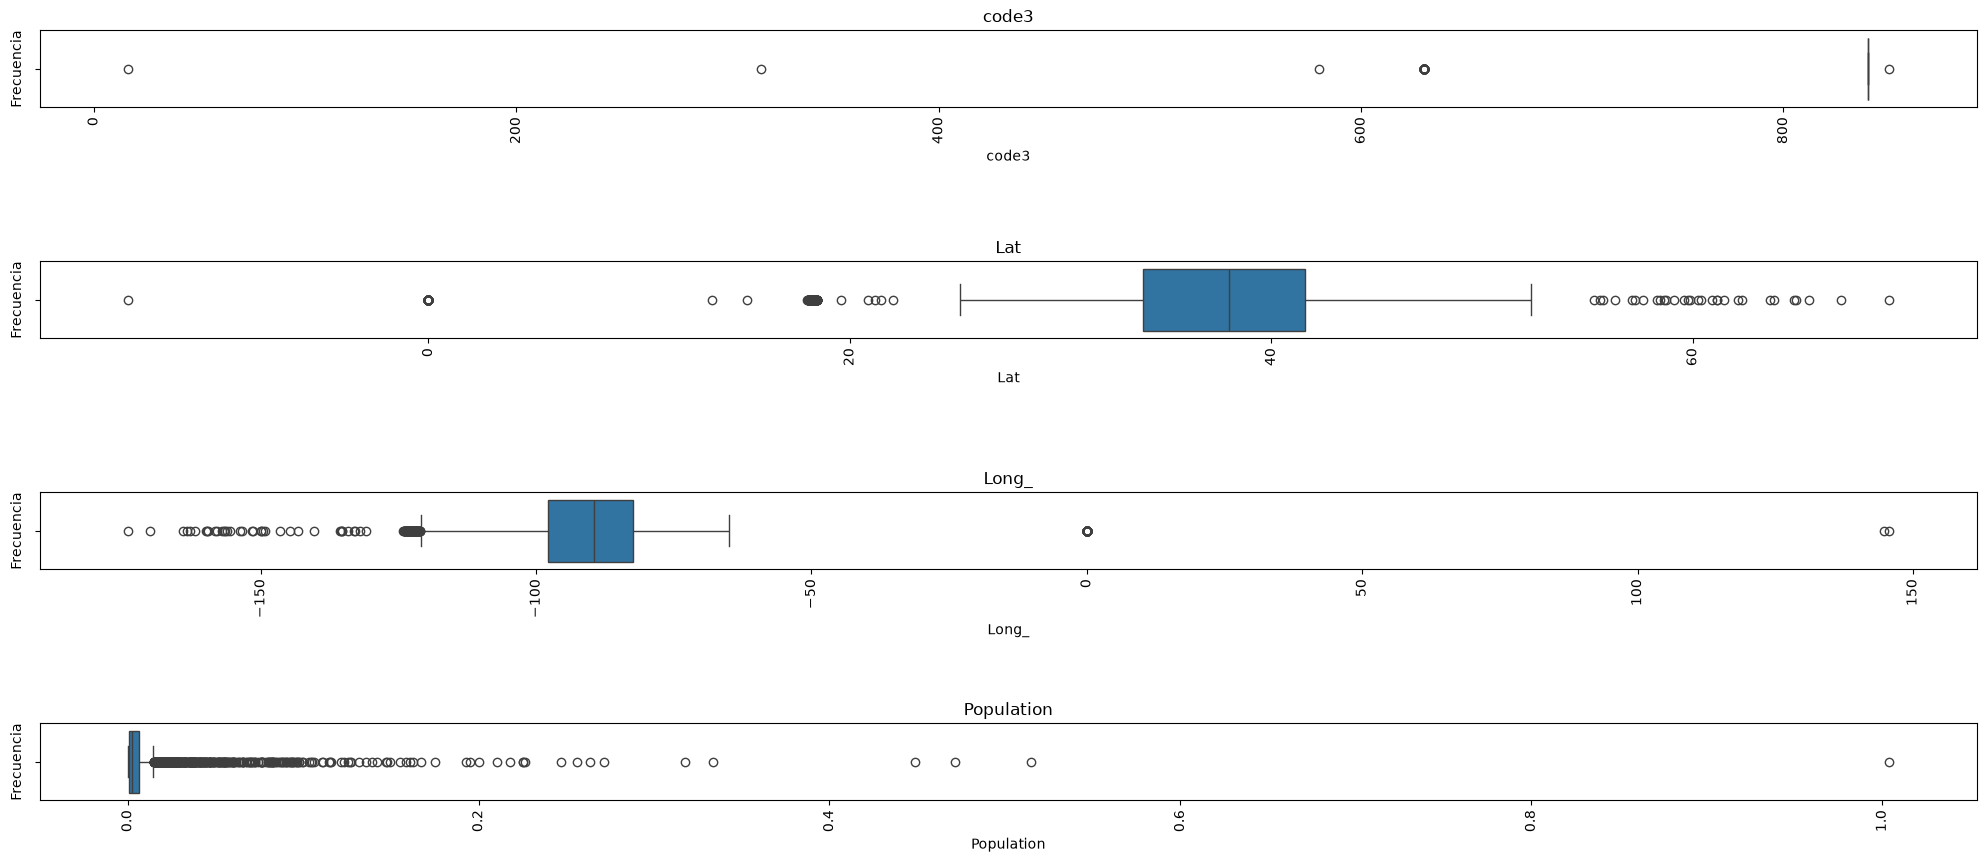

In [97]:
# Analisis de Valores Extremos para Categorias Numericas de la Tabla de Decesos en USA:
outlier_value_analysis(df5_)

- **code3:** es una de las categorias a analizar en cuanto a valores extremos, sin embargo, no es relevante ya que es un codigo identificador, da igual cuan bajo o alto sea su valor respecto a casos confirmados de contagio, muertes y recuperaciones.
- **Lat y Long_:** similar al analisis efectuado en las anteriores tablas, no son categorias analizables determinantes en sus valores extremos.
- **Population (Tabla de Decesos en USA):** pese a que parece interesante analizar cual deberia ser un valor maximo o minimo en la poblacion de un condado en USA, lo cierto es que no existe una regla estricta que delimite esta cantidad, por ello no es analizable.

*Todos los valores de la categorias para todas las tablas resultan dejar en un plano irrelevante la presencia de valores extremos por la naturaleza del dataset y su contexto.*

# 7. Formato de Valores con Regex
Finalmente para terminar con la limpieza de datos, se tiene esta ultima instancia, en la que ya habiendo identificado las columnas o categorias de cada tabla ya se puede decir con certeza cuales de ellas requieren de un formato estricto para sus valores.

Para el caso del presente dataset, solo existe un tipo categorias especiales como **ObservationDate** o **Last Update** que pese a ser del tipo de dato object, realmente reflejan fechas que hasta el momento solo se reflejan como strings de manera interna, por tanto en esta seccion la idea central es dar formato uniforme a dichas fechas.

*La estrategia para este tipo de formateo es primero transformar al tipo de dato de Fecha de pandas y eliminar/reemplazar aquellos valores que no pudieron convertirse correctamente*

## 7.1. Tabla de Datos Globales

Las categorias que contemplan valores de fecha son los siguientes:

- **ObservationDate:** En este caso particular luego de la transformacion a datetime se procede con la eliminacion de registros ya que no es util registros con valor nulo en el lugar donde se especifica cuando se creo.

In [98]:
# Conversion al tipo de dato datetime de pandas:
df1_["ObservationDate"] = pd.to_datetime(df1_["ObservationDate"], format="%m/%d/%Y", errors="coerce")

In [99]:
# Eliminacion de registros mal convertidos:
print("Antes de la eliminacion", df1_.shape[0], "registros.")
df1_ = df1_.dropna(subset=["ObservationDate"])
print("Despues de la eliminacion", df1_.shape[0], "registros.")

Antes de la eliminacion 306429 registros.
Despues de la eliminacion 306429 registros.


- **Last Update:** en este caso no se eliminan los registros tras la transformacion, se procura no poner datos que puedan generar disonancia como la moda, mediana o media, al tratarse de la fecha de ultima modificacion lo mas sensato es hacer el reemplazo por el mismo valor que la columna **ObservationDate**.

In [100]:
# Conversion al tipo de dato datetime de pandas:
df1_["Last Update"] = pd.to_datetime(df1_["Last Update"], format="%m/%d/%Y", errors="coerce")

In [101]:
# Reemplazo de registros nulos de la columna Last Update
df1_["Last Update"] = df1_["Last Update"].fillna(df1_["ObservationDate"])

El proceso de limpieza como primera iteracion puede darse por finalizado en esta instancia, el resto de tablas no presentan categorias con valores de tipo fecha.

## Exportacion de los datos limpios



In [102]:
limpios = {
    "global_data_cleaned.csv":  df1_,
    "confirmed_cleaned.csv":    df2_,
    "confirmed_US_cleaned.csv": df3_,
    "deaths_cleaned.csv":       df4_,
    "deaths_US_cleaned.csv":    df5_,
    "recovered_cleaned.csv":    df6_,
}

for nombre, tabla in limpios.items():
    tabla.to_csv(OUT_DIR / nombre, index=False)
    print(f"Guardado: {OUT_DIR / nombre}  ({tabla.shape[0]} filas, {tabla.shape[1]} columnas)")

if EN_COLAB:
    import shutil
    from google.colab import files
    shutil.make_archive("/content/dataset_limpio", "zip", OUT_DIR)
    files.download("/content/dataset_limpio.zip")

Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/global_data_cleaned.csv  (306429 filas, 8 columnas)
Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/confirmed_cleaned.csv  (274 filas, 498 columnas)
Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/confirmed_US_cleaned.csv  (3332 filas, 503 columnas)
Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/deaths_cleaned.csv  (274 filas, 498 columnas)
Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/deaths_US_cleaned.csv  (3332 filas, 504 columnas)
Guardado: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio/recovered_cleaned.csv  (260 filas, 498 columnas)
